In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import numpy as np
import torch
from inference import FloodInferenceEngine
from hyetograph import build_conditioning_vector
from config import Config
import rasterio
import numpy as np
from rasterio.transform import from_bounds
import rasterio.crs
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import numpy as np
from rasterio.plot import show

# ── Visualization Helpers ─────────────────────────────────────────────────────
FLOOD_COLORS = {
    0: '#FFFFFF', 
    1: '#C6DBEF',  
    2: '#6BAED6',  
    3: '#2171B5',
    4: '#08306B', 
}

FLOOD_LABELS = {0: 'No Flood', 1: 'Light', 2: 'Moderate', 3: 'Heavy', 4: 'Extreme'}
flood_cmap = mcolors.ListedColormap([FLOOD_COLORS[i] for i in range(5)])
flood_norm = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5], ncolors=5)
legend_patches = [
    mpatches.Patch(facecolor=FLOOD_COLORS[i], edgecolor='gray',
                   linewidth=0.5, label=f'Class {i} — {FLOOD_LABELS[i]}')
    for i in range(5)
]

# ── Predict with Confidence ───────────────────────────────────────────────────
@torch.no_grad()
def predict_with_confidence(engine, storm_type, depth_mm, hasDrainage, hasSoil,
                             tpeak=None, batch_size=512):
    conditioning_np, warnings = build_conditioning_vector(
        storm_type  = storm_type,
        depth_mm    = depth_mm,
        rain_min    = engine.rain_min,
        rain_max    = engine.rain_max,
        depth_min   = engine.depth_min,   
        depth_max   = engine.depth_max,   
        hasDrainage = hasDrainage,
        hasSoil     = hasSoil,
        tpeak       = tpeak,
    )
    conditioning_all = np.tile(conditioning_np[np.newaxis], (engine.patches_per_map, 1))
    spatial_all = np.stack([
        engine._apply_channel_masking(engine.spatial_patches[i], hasDrainage, hasSoil)
        for i in range(engine.patches_per_map)
    ])
    patch_preds = []
    patch_confs = []
    for start in range(0, engine.patches_per_map, batch_size):
        end           = min(start + batch_size, engine.patches_per_map)
        spatial_batch = torch.from_numpy(spatial_all[start:end]).float().to(engine.device)
        cond_batch    = torch.from_numpy(conditioning_all[start:end]).float().to(engine.device)
        logits, _     = engine.model(spatial_batch, cond_batch)
        probs         = torch.softmax(logits, dim=1)
        patch_preds.append(probs.argmax(dim=1).cpu().numpy())
        patch_confs.append(probs.max(dim=1).values.cpu().numpy())
    patch_preds = np.concatenate(patch_preds)
    patch_confs = np.concatenate(patch_confs)
    return {
        'flood_map'  : engine._reconstruct_map(patch_preds),
        'conf_map'   : engine._reconstruct_map(patch_confs.astype(np.float32)),
        'patch_preds': patch_preds,
        'patch_confs': patch_confs,
        'warnings'   : warnings,
        'config'     : {
            'storm_type' : storm_type,
            'depth_mm'   : depth_mm,
            'tpeak'      : tpeak,
            'hasDrainage': hasDrainage,
            'hasSoil'    : hasSoil,
        },
    }

def visualize_result_tif(
    tif_path    : str,
    save_path   : str = None,
    figsize     : tuple = (21, 6),
) -> None:
    flood_cmap = mcolors.ListedColormap([FLOOD_COLORS[i] for i in range(5)])
    flood_norm = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5], ncolors=5)
    conf_cmap  = 'RdYlGn'

    with rasterio.open(tif_path) as src:
        band1     = src.read(1)                  # flood class
        band2     = src.read(2)                  # confidence
        band3     = src.read(3) if src.count >= 3 else None   # barangay PSGC
        extent    = [
            src.bounds.left, src.bounds.right,
            src.bounds.bottom, src.bounds.top,
        ]
        crs       = src.crs
        tags      = src.tags()
        b1_tags   = src.tags(1)
        b2_tags   = src.tags(2)
        b3_tags   = src.tags(3) if src.count >= 3 else {}

    # ── Print metadata ────────────────────────────────────────────────────────
    print(f"\nGeoTIFF: {tif_path}")
    print(f"  CRS       : {crs}")
    print(f"  Extent    : {extent}")
    print(f"  Band 1    : {b1_tags.get('description', 'Flood class')}")
    print(f"  Band 2    : {b2_tags.get('description', 'Confidence')}")
    if band3 is not None:
        print(f"  Band 3    : {b3_tags.get('description', 'Barangay PSGC Code')}")
    print(f"  Storm     : {tags.get('storm_type','?')}  "
          f"{tags.get('depth_mm','?')}mm  "
          f"tpeak={tags.get('tpeak','?')}  "
          f"Drainage={tags.get('hasDrainage','?')}  "
          f"Soil={tags.get('hasSoil','?')}")

    # ── Figure ────────────────────────────────────────────────────────────────
    n_cols = 3 if band3 is not None else 2
    fig, axes = plt.subplots(1, n_cols, figsize=figsize)

    # ── Band 1: Flood class ───────────────────────────────────────────────────
    ax1 = axes[0]
    im1 = ax1.imshow(
        band1, cmap=flood_cmap, norm=flood_norm,
        extent=extent, interpolation='nearest',
        origin='upper',
    )
    ax1.set_title(
        f"Band 1 — Flood Hazard Class\n"
        f"Storm: {tags.get('storm_type','?')}  |  "
        f"Depth: {tags.get('depth_mm','?')} mm  |  "
        f"tpeak: {tags.get('tpeak','?')}",
        fontsize=9, fontweight='bold', pad=6,
    )
    ax1.set_xlabel('Longitude', fontsize=8)
    ax1.set_ylabel('Latitude',  fontsize=8)
    ax1.tick_params(labelsize=7)

    # Flood class legend
    legend_patches = [
        mpatches.Patch(facecolor=FLOOD_COLORS[i], edgecolor='gray',
                       linewidth=0.5, label=f'Class {i} — {FLOOD_LABELS[i]}')
        for i in range(5)
    ]
    ax1.legend(handles=legend_patches, loc='lower left', fontsize=7,
               framealpha=0.85, title='Flood Class', title_fontsize=7)

    # Class distribution annotation
    total = band1.size
    dist  = '\n'.join([
        f"C{i} {FLOOD_LABELS[i]}: {100*(band1==i).sum()/total:.1f}%"
        for i in range(5)
    ])
    ax1.text(
        0.98, 0.98, dist,
        transform=ax1.transAxes, ha='right', va='top',
        fontsize=6.5,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                  edgecolor='lightgray', alpha=0.88),
    )

    # ── Band 2: Confidence ────────────────────────────────────────────────────
    ax2  = axes[1]
    im2  = ax2.imshow(
        band2, cmap=conf_cmap, vmin=0.0, vmax=1.0,
        extent=extent, interpolation='nearest',
        origin='upper',
    )
    ax2.set_title(
        f"Band 2 — Model Confidence\n"
        f"Drainage: {'✓' if tags.get('hasDrainage')=='True' else '✗'}  |  "
        f"Soil: {'✓' if tags.get('hasSoil')=='True' else '✗'}",
        fontsize=9, fontweight='bold', pad=6,
    )
    ax2.set_xlabel('Longitude', fontsize=8)
    ax2.set_ylabel('Latitude',  fontsize=8)
    ax2.tick_params(labelsize=7)

    # Colorbar
    cbar = fig.colorbar(im2, ax=ax2, fraction=0.035, pad=0.04)
    cbar.set_label('Confidence', fontsize=8)
    cbar.ax.tick_params(labelsize=7)
    cbar.set_ticks([0.0, 0.25, 0.5, 0.75, 1.0])
    cbar.ax.axhline(y=0.5, color='black', linewidth=1.2, linestyle='--')
    cbar.ax.text(2.3, 0.5, 'uncertain\nthreshold',
                 fontsize=6, va='center', color='black')

    # Uncertain patch overlay
    uncertain_overlay = band2.copy()
    uncertain_overlay[band2 >= 0.5] = np.nan
    uncertain_overlay[band2 <  0.5] = 1.0
    ax2.imshow(uncertain_overlay, cmap='cool', alpha=0.30,
               vmin=0, vmax=1, extent=extent,
               interpolation='nearest', origin='upper')

    # Confidence stats annotation
    frac_low = (band2 < 0.5).mean() * 100
    stats    = (
        f"Mean : {band2.mean():.3f}\n"
        f"Std  : {band2.std():.3f}\n"
        f"Min  : {band2.min():.3f}\n"
        f"Max  : {band2.max():.3f}\n"
        f"Uncertain: {frac_low:.1f}%"
    )
    ax2.text(
        0.98, 0.98, stats,
        transform=ax2.transAxes, ha='right', va='top',
        fontsize=6.5,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                  edgecolor='lightgray', alpha=0.88),
    )

    # ── Band 3: Barangay PSGC Code ────────────────────────────────────────────
    if band3 is not None:
        ax3 = axes[2]

        # Mask zeros (background / nodata) so they render as white
        bar_masked = np.ma.masked_equal(band3, 0)

        # Build a qualitative colormap with enough unique colors
        unique_codes = np.unique(band3[band3 > 0])
        n_unique     = max(len(unique_codes), 1)
        bar_cmap     = plt.cm.get_cmap('tab20', n_unique)
        bar_cmap.set_bad(color='white')   # masked (background) → white

        im3 = ax3.imshow(
            bar_masked, cmap=bar_cmap,
            extent=extent, interpolation='nearest',
            origin='upper',
        )
        ax3.set_title(
            f"Band 3 — Barangay Boundaries\n"
            f"PSGC codes  |  {n_unique} barangay(s) in extent",
            fontsize=9, fontweight='bold', pad=6,
        )
        ax3.set_xlabel('Longitude', fontsize=8)
        ax3.set_ylabel('Latitude',  fontsize=8)
        ax3.tick_params(labelsize=7)

        # Colorbar showing PSGC code range
        cbar3 = fig.colorbar(im3, ax=ax3, fraction=0.035, pad=0.04)
        cbar3.set_label('PSGC Code', fontsize=8)
        cbar3.ax.tick_params(labelsize=7)

        # Stats annotation
        bar_stats = (
            f"Barangays : {n_unique}\n"
            f"Min code  : {int(unique_codes.min()) if n_unique else 'N/A'}\n"
            f"Max code  : {int(unique_codes.max()) if n_unique else 'N/A'}\n"
            f"Coverage  : {100*(band3>0).mean():.1f}%"
        )
        ax3.text(
            0.98, 0.98, bar_stats,
            transform=ax3.transAxes, ha='right', va='top',
            fontsize=6.5,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor='lightgray', alpha=0.88),
        )

    fig.suptitle(
        f'EXP-DES-2 — GeoTIFF Result Visualization\n{tif_path}',
        fontsize=10, fontweight='bold', y=1.02,
    )
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
        print(f"✓ Visualization saved → {save_path}")

    plt.show()


def save_result_as_tif(result: dict, save_path: str, transform, crs, map_size: tuple = (320, 320),
                        barangay_tif: str = None) -> None:
    from rasterio.enums import Resampling
    from rasterio.warp import reproject, calculate_default_transform

    flood_map = result['flood_map'].astype(np.float32)   # (320, 320)
    conf_map  = result['conf_map'].astype(np.float32)    # (320, 320)
    H, W      = map_size

    # ── Load & reproject barangay raster to match output grid ────────────────
    barangay_band = None
    if barangay_tif is not None:
        with rasterio.open(barangay_tif) as bar_src:
            barangay_band = np.zeros((H, W), dtype=np.float32)
            reproject(
                source      = rasterio.band(bar_src, 1),
                destination = barangay_band,
                src_transform  = bar_src.transform,
                src_crs        = bar_src.crs,
                dst_transform  = transform,
                dst_crs        = crs,
                resampling     = Resampling.nearest,
            )

    n_bands = 3 if barangay_band is not None else 2

    with rasterio.open(
        save_path,
        mode      = 'w',
        driver    = 'GTiff',
        height    = H,
        width     = W,
        count     = n_bands,
        dtype     = 'float32',
        crs       = crs,
        transform = transform,
        compress  = 'lzw',
    ) as dst:
        dst.write(flood_map, 1)   # Band 1 — flood class
        dst.write(conf_map,  2)   # Band 2 — confidence
        if barangay_band is not None:
            dst.write(barangay_band, 3)   # Band 3 — barangay PSGC code

        # Band descriptions — readable in QGIS / ArcGIS
        dst.update_tags(1, description='Flood Hazard Class (0=None 1=Light 2=Moderate 3=Heavy 4=Extreme)')
        dst.update_tags(2, description='Model Confidence (softmax max-probability per patch 0.0-1.0)')
        if barangay_band is not None:
            dst.update_tags(3, description='Barangay PSGC Code (reprojected from manila_barangay.tif)')

        # File-level metadata
        dst.update_tags(
            model       = 'EXP-DES-2 ViTFloodClassifier',
            storm_type  = result['config']['storm_type'],
            depth_mm    = str(result['config']['depth_mm']),
            tpeak       = str(result['config']['tpeak']),
            hasDrainage = str(result['config']['hasDrainage']),
            hasSoil     = str(result['config']['hasSoil']),
        )

    print(f"✓ GeoTIFF saved → {save_path}")
    print(f"  Band 1 : Flood class  (float32, 0–4)")
    print(f"  Band 2 : Confidence   (float32, 0.0–1.0)")
    if barangay_band is not None:
        print(f"  Band 3 : Barangay PSGC code (float32, reprojected)")
    print(f"  CRS    : {crs}")
    print(f"  Size   : {W}×{H} px")
    print(f"  Transform : {transform}")


def build_subtitle(cfg: dict) -> str:
    parts = [f"Storm: {cfg['storm_type']}", f"Depth: {cfg['depth_mm']} mm"]
    if cfg['tpeak'] is not None:
        parts.append(f"tpeak: {cfg['tpeak']}")
    parts.append(f"Drainage: {'✓' if cfg['hasDrainage'] else '✗'}")
    parts.append(f"Soil: {'✓' if cfg['hasSoil'] else '✗'}")
    return '  |  '.join(parts)

def compute_class_pcts(flood_map):
    total = flood_map.size
    return {i: 100 * (flood_map == i).sum() / total for i in range(5)}

def add_warning_banner(ax, warnings):
    if warnings:
        ax.text(
            0.5, 0.02,
            f'⚠ {len(warnings)} warning(s) — inputs outside training range',
            transform=ax.transAxes, ha='center', va='bottom',
            fontsize=7.5, color='white',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#B8860B',
                      edgecolor='none', alpha=0.88),
        )

  Best fold   : 2
  Model path  : checkpoints\fold_2\best_model.pt
✓ Spatial patches loaded: (6400, 11, 4, 4)
  Best macro F1 (saved): 0.5164
✓ Model loaded from: checkpoints\fold_2\best_model.pt
  Device : cpu
  Patches: 6,400 per prediction


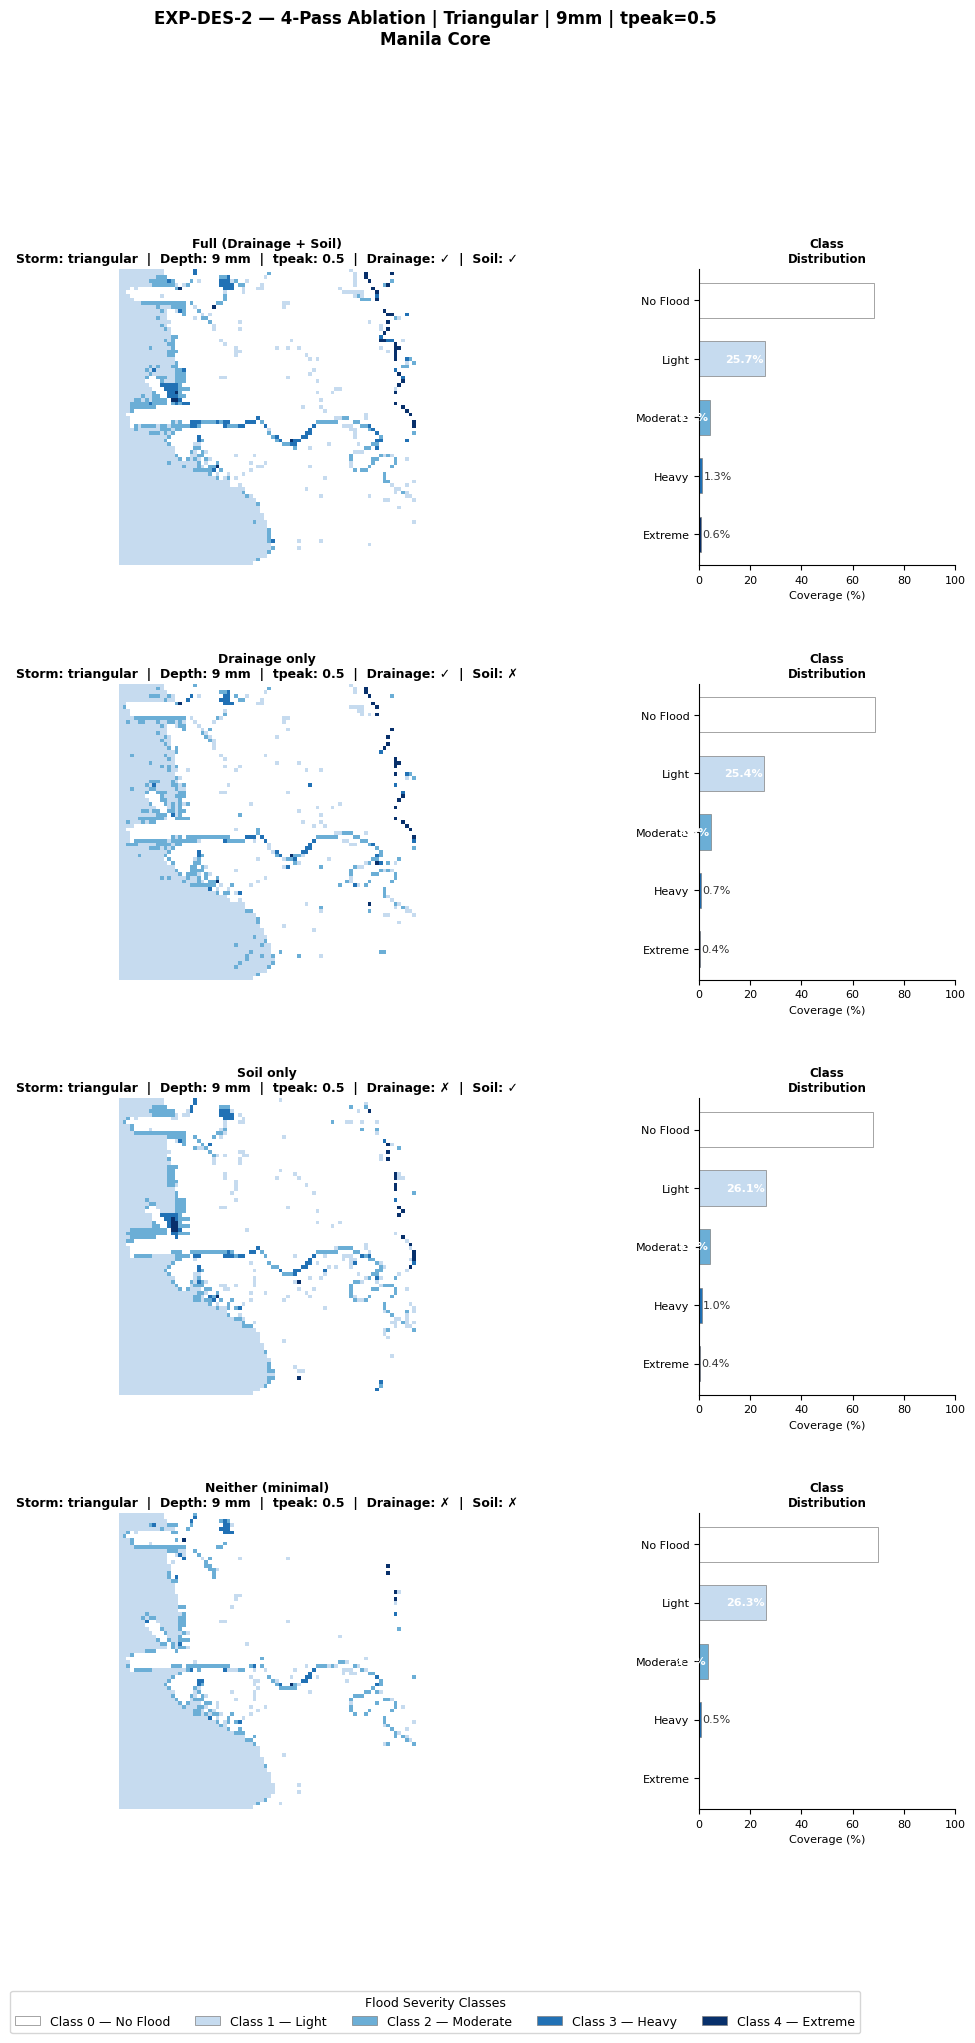

✓ Saved → checkpoints\ablation_flood_triangular_9mm.png


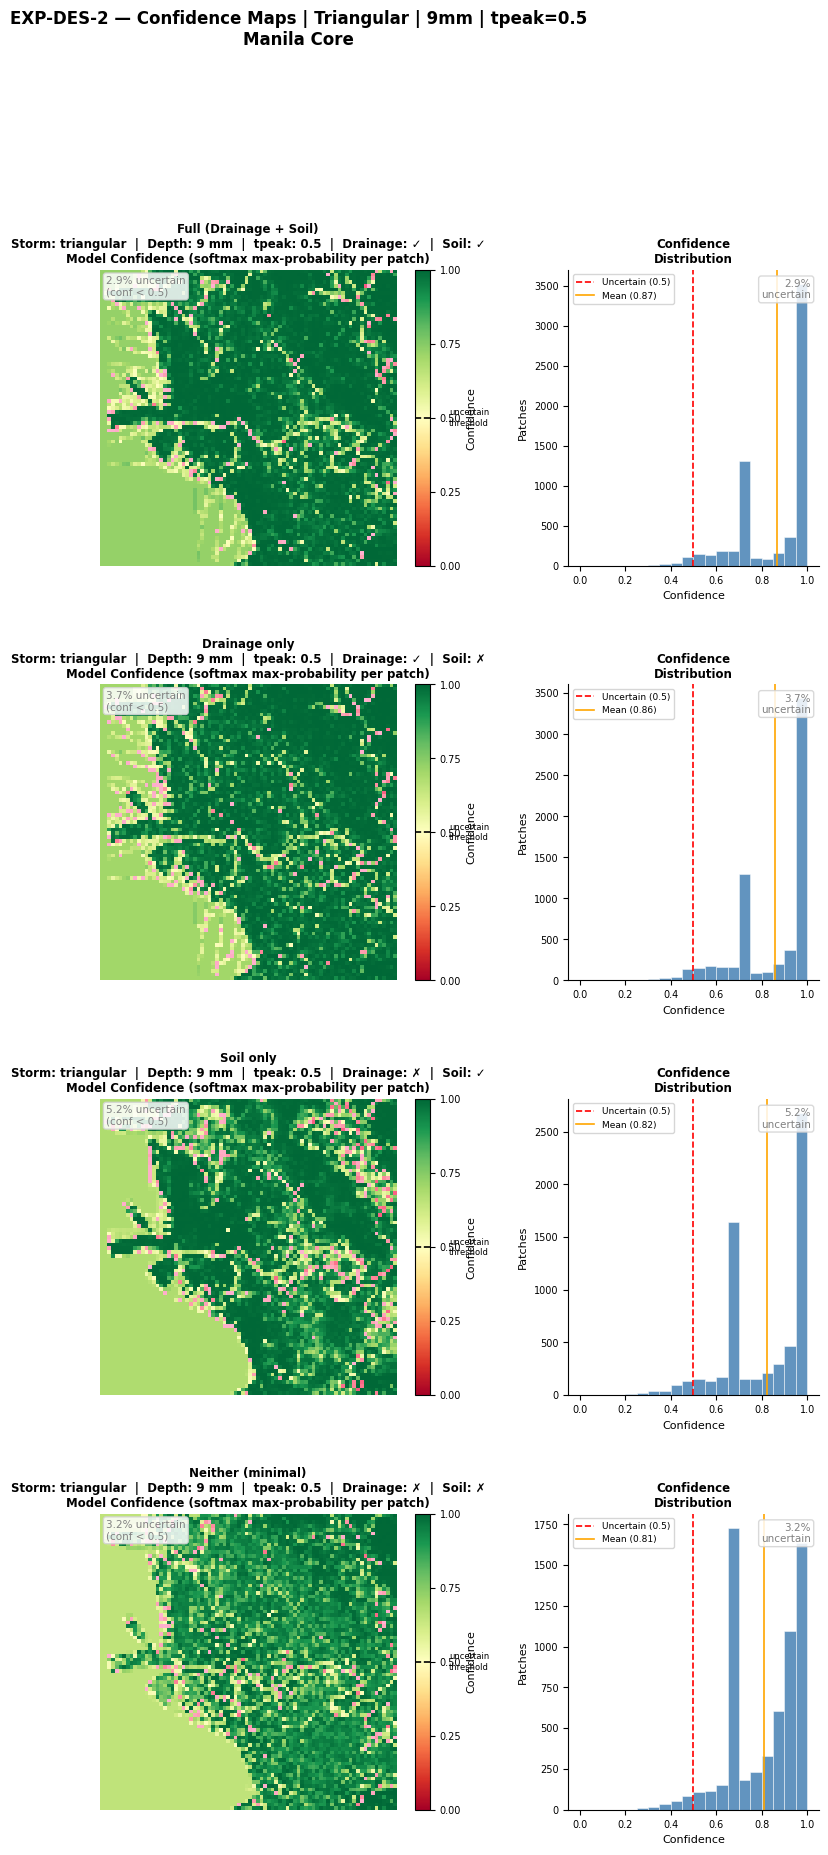

✓ Saved → checkpoints\ablation_conf_triangular_9mm.png


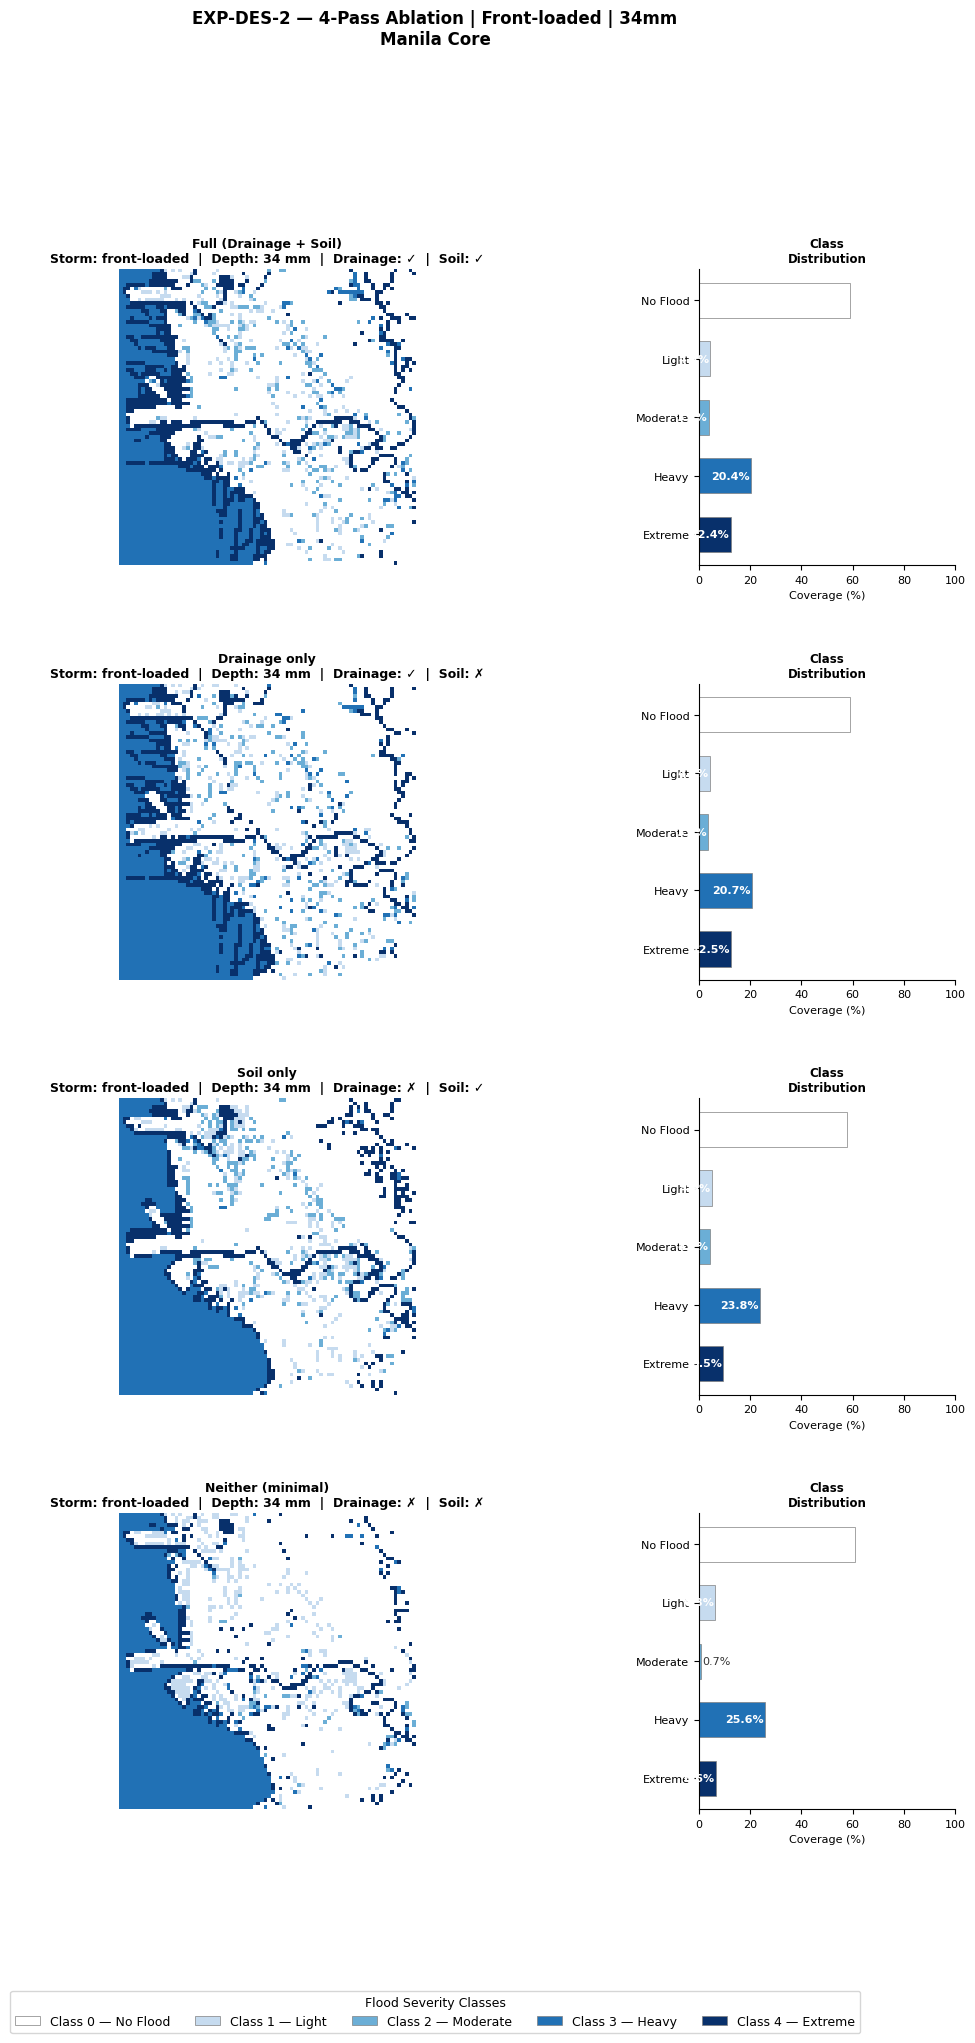

✓ Saved → checkpoints\ablation_flood_front_loaded_34mm.png


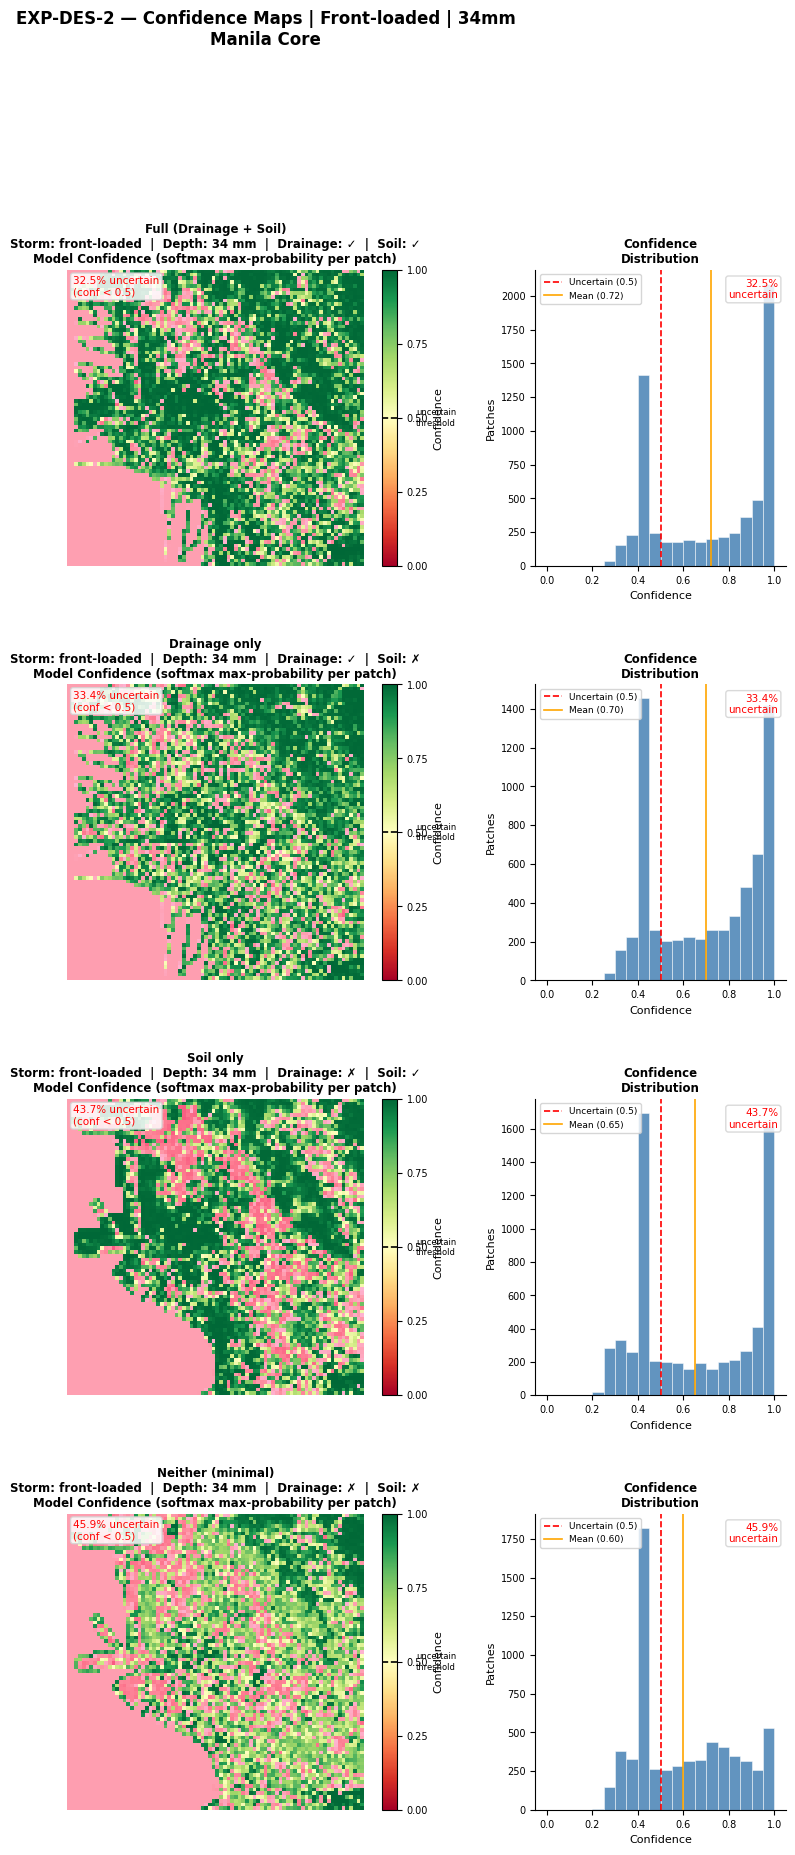

✓ Saved → checkpoints\ablation_conf_front_loaded_34mm.png


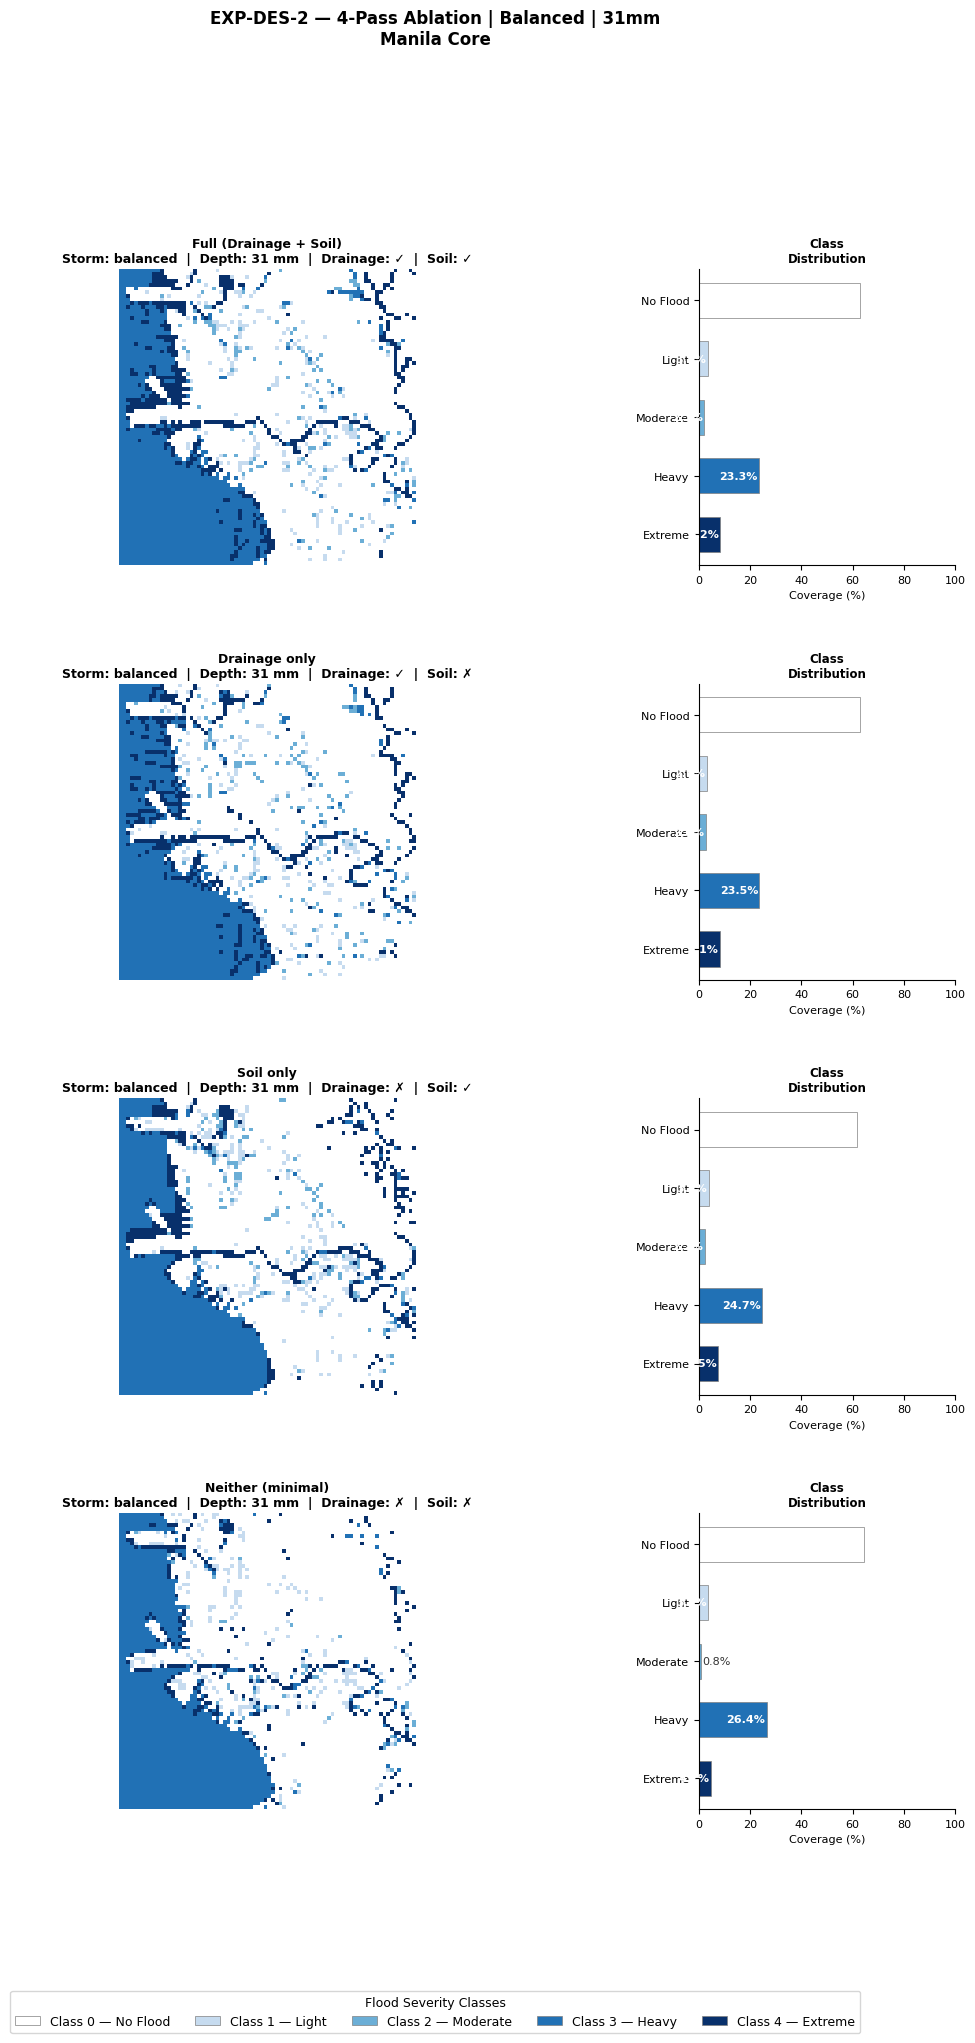

✓ Saved → checkpoints\ablation_flood_balanced_31mm.png


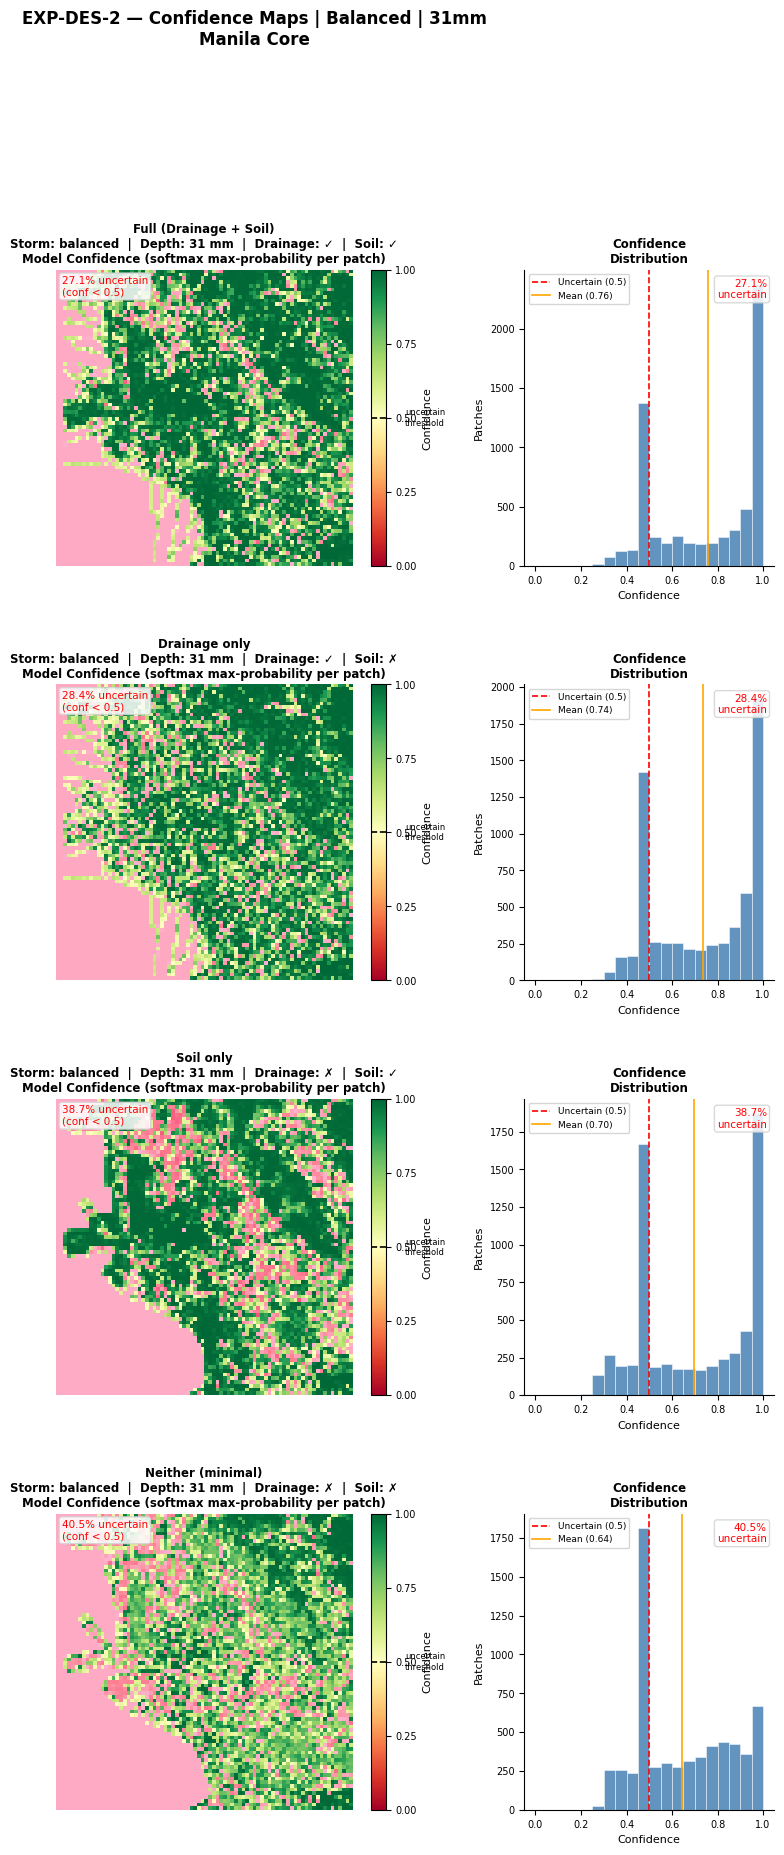

✓ Saved → checkpoints\ablation_conf_balanced_31mm.png


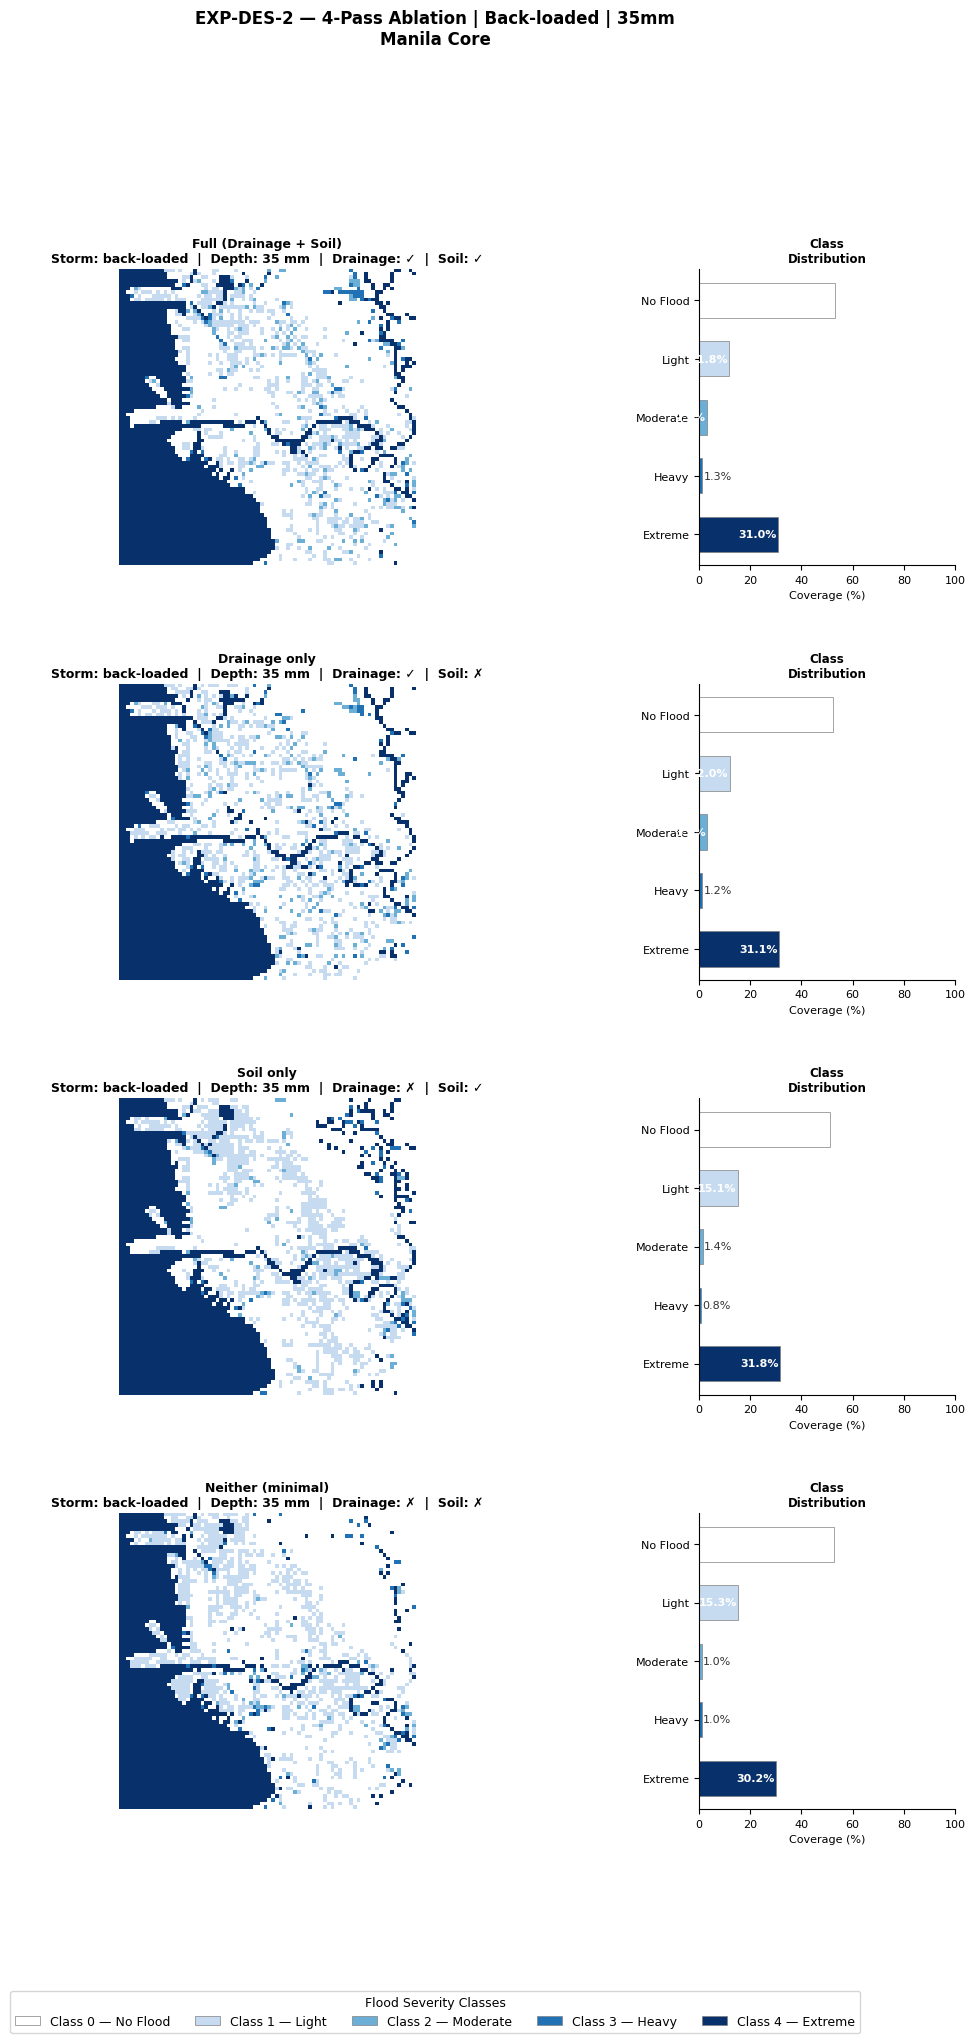

✓ Saved → checkpoints\ablation_flood_back_loaded_35mm.png


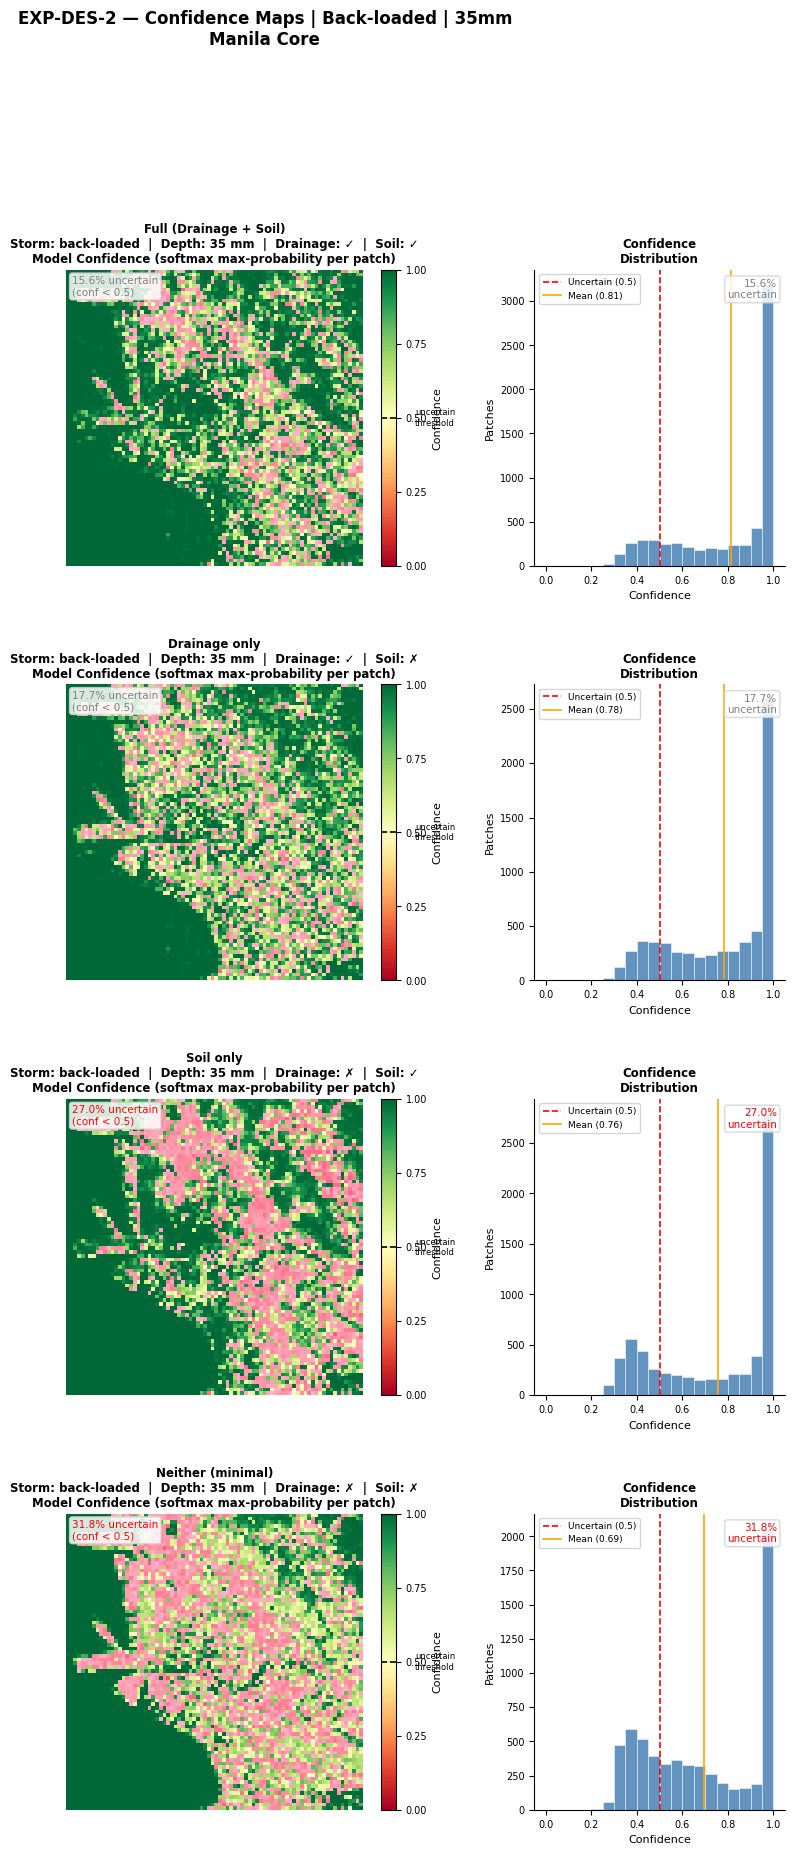

✓ Saved → checkpoints\ablation_conf_back_loaded_35mm.png

FULL ABLATION SUMMARY — ALL STORM TYPES

  Triangular | 9mm | tpeak=0.5
  Config                      AvgConf  Uncertain%  NoFlood%  Light%   Mod%  Heavy%  Extreme%
  ----------------------------------------------------------------------------------------
  Full (Drainage + Soil)       0.8667        2.9%     68.3%   25.7%   4.1%    1.3%      0.6%
  Drainage only                0.8575        3.7%     68.9%   25.4%   4.6%    0.7%      0.4%
  Soil only                    0.8219        5.2%     68.1%   26.1%   4.3%    1.0%      0.4%
  Neither (minimal)            0.8083        3.2%     69.8%   26.3%   3.3%    0.5%      0.1%

  Front-loaded | 34mm
  Config                      AvgConf  Uncertain%  NoFlood%  Light%   Mod%  Heavy%  Extreme%
  ----------------------------------------------------------------------------------------
  Full (Drainage + Soil)       0.7222       32.5%     59.0%    4.4%   3.7%   20.4%     12.4%
  Drainage onl

In [2]:
# ── Config & Engine ───────────────────────────────────────────────────────────
cfg = Config()

engine = FloodInferenceEngine(
    inference_config_path = 'checkpoints/inference_config.json',
    spatial_data_path     = 'checkpoints/spatial_data.npz',
)

# ══════════════════════════════════════════════════════════════════════════════
# 4-PASS ABLATION PER STORM TYPE
# Configs: Full | Drainage only | Soil only | Neither (minimal)
# Storm types & depths (all from actual training scenarios):
#   Triangular  :  9mm, tpeak=0.5  → RS31
#   Front-loaded: 34mm             → RS3
#   Balanced    : 31mm             → RS18
#   Back-loaded : 35mm             → RS23
# ══════════════════════════════════════════════════════════════════════════════

ABLATION_CONFIGS = [
    dict(label='Full (Drainage + Soil)',  hasDrainage=True,  hasSoil=True),
    dict(label='Drainage only',           hasDrainage=True,  hasSoil=False),
    dict(label='Soil only',               hasDrainage=False, hasSoil=True),
    dict(label='Neither (minimal)',       hasDrainage=False, hasSoil=False),
]

STORM_CONFIGS = [
    dict(storm_type='triangular',   depth_mm=9,  tpeak=0.5, storm_label='Triangular | 9mm | tpeak=0.5'),
    dict(storm_type='front-loaded', depth_mm=34, tpeak=None, storm_label='Front-loaded | 34mm'),
    dict(storm_type='balanced',     depth_mm=31, tpeak=None, storm_label='Balanced | 31mm'),
    dict(storm_type='back-loaded',  depth_mm=35, tpeak=None, storm_label='Back-loaded | 35mm'),
]

# ── Run all predictions ───────────────────────────────────────────────────────
# results[storm_label][ablation_label] = result dict
all_results = {}
for sc in STORM_CONFIGS:
    all_results[sc['storm_label']] = {}
    for ab in ABLATION_CONFIGS:
        all_results[sc['storm_label']][ab['label']] = predict_with_confidence(
            engine,
            storm_type  = sc['storm_type'],
            depth_mm    = sc['depth_mm'],
            tpeak       = sc['tpeak'],
            hasDrainage = ab['hasDrainage'],
            hasSoil     = ab['hasSoil'],
        )

# ── Helper: plot one storm's 4-pass ablation (flood maps) ────────────────────
def plot_4pass_flood(storm_label, save_name):
    """4 rows (one per ablation config) × 2 cols (flood map | bar chart)"""
    fig, axes = plt.subplots(
        4, 2, figsize=(13, 20),
        gridspec_kw={'width_ratios': [2.5, 1], 'hspace': 0.40, 'wspace': 0.25}
    )
    for row, ab in enumerate(ABLATION_CONFIGS):
        result   = all_results[storm_label][ab['label']]
        ax_flood = axes[row, 0]
        ax_bar   = axes[row, 1]
        pcts     = compute_class_pcts(result['flood_map'])

        ax_flood.imshow(result['flood_map'], cmap=flood_cmap, norm=flood_norm,
                        interpolation='nearest')
        ax_flood.set_title(
            f"{ab['label']}\n{build_subtitle(result['config'])}",
            fontsize=9, fontweight='bold', pad=5)
        ax_flood.axis('off')
        add_warning_banner(ax_flood, result['warnings'])

        bar_labels = [FLOOD_LABELS[i] for i in range(5)]
        values     = [pcts[i] for i in range(5)]
        colors     = [FLOOD_COLORS[i] for i in range(5)]
        bars       = ax_bar.barh(bar_labels, values, color=colors,
                                 edgecolor='gray', linewidth=0.5, height=0.6)
        for bar, val in zip(bars, values):
            if val > 1.5:
                ax_bar.text(bar.get_width() - 0.5,
                            bar.get_y() + bar.get_height() / 2,
                            f'{val:.1f}%', va='center', ha='right',
                            fontsize=8, color='white', fontweight='bold')
            elif val > 0.1:
                ax_bar.text(bar.get_width() + 0.5,
                            bar.get_y() + bar.get_height() / 2,
                            f'{val:.1f}%', va='center', ha='left',
                            fontsize=8, color='#333333')
        ax_bar.set_xlim(0, 100)
        ax_bar.set_xlabel('Coverage (%)', fontsize=8)
        ax_bar.set_title('Class\nDistribution', fontsize=8.5,
                         fontweight='bold', pad=5)
        ax_bar.tick_params(axis='both', labelsize=8)
        ax_bar.spines['top'].set_visible(False)
        ax_bar.spines['right'].set_visible(False)
        ax_bar.invert_yaxis()

    fig.legend(handles=legend_patches, loc='lower center', ncol=5, fontsize=9,
               frameon=True, title='Flood Severity Classes', title_fontsize=9,
               bbox_to_anchor=(0.5, -0.005))
    fig.suptitle(
        f'EXP-DES-2 — 4-Pass Ablation | {storm_label}\nManila Core',
        fontsize=12, fontweight='bold', y=1.01)
    path = str(cfg.train.output_dir / save_name)
    plt.savefig(path, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'✓ Saved → {path}')


# ── Helper: plot one storm's 4-pass ablation (confidence maps) ───────────────
def plot_4pass_confidence(storm_label, save_name):
    """4 rows (one per ablation config) × 2 cols (confidence map | histogram)"""
    fig, axes = plt.subplots(
        4, 2, figsize=(13, 20),
        gridspec_kw={'width_ratios': [2.5, 1], 'hspace': 0.40, 'wspace': 0.30}
    )
    conf_cmap = 'RdYlGn'
    for row, ab in enumerate(ABLATION_CONFIGS):
        result      = all_results[storm_label][ab['label']]
        ax_conf     = axes[row, 0]
        ax_hist     = axes[row, 1]
        conf_map    = result['conf_map']
        patch_confs = result['patch_confs']
        frac_low    = (patch_confs < 0.5).mean() * 100

        im = ax_conf.imshow(conf_map, cmap=conf_cmap, vmin=0.0, vmax=1.0,
                            interpolation='nearest')
        ax_conf.set_title(
            f"{ab['label']}\n{build_subtitle(result['config'])}\n"
            f"Model Confidence (softmax max-probability per patch)",
            fontsize=8.5, fontweight='bold', pad=5)
        ax_conf.axis('off')
        add_warning_banner(ax_conf, result['warnings'])

        cbar = plt.colorbar(im, ax=ax_conf, fraction=0.035, pad=0.03)
        cbar.set_label('Confidence', fontsize=8)
        cbar.ax.tick_params(labelsize=7)
        cbar.set_ticks([0.0, 0.25, 0.5, 0.75, 1.0])
        cbar.ax.axhline(y=0.5, color='black', linewidth=1.2, linestyle='--')
        cbar.ax.text(2.3, 0.5, 'uncertain\nthreshold', fontsize=6,
                     va='center', color='black')

        uncertain_overlay = conf_map.copy().astype(float)
        uncertain_overlay[conf_map >= 0.5] = np.nan
        uncertain_overlay[conf_map <  0.5] = 1.0
        ax_conf.imshow(uncertain_overlay, cmap='cool', alpha=0.30,
                       vmin=0, vmax=1, interpolation='nearest')
        ax_conf.text(0.02, 0.98, f'{frac_low:.1f}% uncertain\n(conf < 0.5)',
                     transform=ax_conf.transAxes, ha='left', va='top',
                     fontsize=7.5,
                     color='red' if frac_low > 20 else 'gray',
                     bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                               edgecolor='lightgray', alpha=0.85))

        ax_hist.hist(patch_confs, bins=20, range=(0, 1), color='steelblue',
                     edgecolor='white', linewidth=0.4, alpha=0.85)
        ax_hist.axvline(x=0.5, color='red', linewidth=1.2, linestyle='--',
                        label='Uncertain (0.5)')
        ax_hist.axvline(x=patch_confs.mean(), color='orange', linewidth=1.2,
                        linestyle='-', label=f"Mean ({patch_confs.mean():.2f})")
        ax_hist.set_xlabel('Confidence', fontsize=8)
        ax_hist.set_ylabel('Patches', fontsize=8)
        ax_hist.set_title('Confidence\nDistribution', fontsize=8.5,
                          fontweight='bold', pad=5)
        ax_hist.tick_params(labelsize=7)
        ax_hist.legend(fontsize=6.5, loc='upper left')
        ax_hist.spines['top'].set_visible(False)
        ax_hist.spines['right'].set_visible(False)
        ax_hist.text(0.97, 0.97, f'{frac_low:.1f}%\nuncertain',
                     transform=ax_hist.transAxes, ha='right', va='top',
                     fontsize=7.5,
                     color='red' if frac_low > 20 else 'gray',
                     bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                               edgecolor='lightgray', alpha=0.85))

    fig.suptitle(
        f'EXP-DES-2 — Confidence Maps | {storm_label}\nManila Core',
        fontsize=12, fontweight='bold', y=1.01)
    path = str(cfg.train.output_dir / save_name)
    plt.savefig(path, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'✓ Saved → {path}')


# ── Generate all figures ──────────────────────────────────────────────────────
save_slugs = {
    'Triangular | 9mm | tpeak=0.5' : 'triangular_9mm',
    'Front-loaded | 34mm'          : 'front_loaded_34mm',
    'Balanced | 31mm'              : 'balanced_31mm',
    'Back-loaded | 35mm'           : 'back_loaded_35mm',
}

for sc in STORM_CONFIGS:
    slug = save_slugs[sc['storm_label']]
    plot_4pass_flood(sc['storm_label'],
                     save_name=f'ablation_flood_{slug}.png')
    plot_4pass_confidence(sc['storm_label'],
                          save_name=f'ablation_conf_{slug}.png')


# ── Cross-storm × cross-ablation summary table ────────────────────────────────
print('\n' + '='*75)
print('FULL ABLATION SUMMARY — ALL STORM TYPES')
print('='*75)

for sc in STORM_CONFIGS:
    print(f'\n  {sc["storm_label"]}')
    print(f'  {"Config":<26} {"AvgConf":>8} {"Uncertain%":>11} '
          f'{"NoFlood%":>9} {"Light%":>7} {"Mod%":>6} {"Heavy%":>7} {"Extreme%":>9}')
    print(f'  {"-"*88}')
    for ab in ABLATION_CONFIGS:
        result      = all_results[sc['storm_label']][ab['label']]
        patch_confs = result['patch_confs']
        pcts        = compute_class_pcts(result['flood_map'])
        print(
            f'  {ab["label"]:<26} '
            f'{patch_confs.mean():>8.4f} '
            f'{100*(patch_confs<0.5).mean():>10.1f}% '
            f'{pcts[0]:>8.1f}% '
            f'{pcts[1]:>6.1f}% '
            f'{pcts[2]:>5.1f}% '
            f'{pcts[3]:>6.1f}% '
            f'{pcts[4]:>8.1f}%'
        )

In [3]:
dem_crs       = rasterio.crs.CRS.from_epsg(3857)
dem_transform = rasterio.transform.Affine(30.0, 0.0, 13462980.0, 0.0, -30.0, 1647690.0)

# ── Save all 16 results (4 storm types × 4 ablation configs) ─────────────────
ablation_slugs = {
    'Full (Drainage + Soil)' : 'full',
    'Drainage only'          : 'drain_only',
    'Soil only'              : 'soil_only',
    'Neither (minimal)'      : 'minimal',
}

for sc in STORM_CONFIGS:
    slug = save_slugs[sc['storm_label']]
    for ab in ABLATION_CONFIGS:
        ab_slug  = ablation_slugs[ab['label']]
        result   = all_results[sc['storm_label']][ab['label']]
        filename = f'inference_{slug}_{ab_slug}.tif'

        save_result_as_tif(
            result       = result,
            save_path    = str(cfg.train.output_dir / filename),
            transform    = dem_transform,
            crs          = dem_crs,
            barangay_tif = 'manila_barangay.tif',  # Band 3: barangay PSGC codes
        )

print('\n✓ All 16 GeoTIFFs saved')
print(f'  Location: {cfg.train.output_dir}')
print('\n  Files:')
for sc in STORM_CONFIGS:
    slug = save_slugs[sc['storm_label']]
    for ab in ABLATION_CONFIGS:
        ab_slug = ablation_slugs[ab['label']]
        print(f'    inference_{slug}_{ablation_slugs[ab["label"]]}.tif  ←  '
              f'{sc["storm_label"]} | {ab["label"]}')

✓ GeoTIFF saved → checkpoints\inference_triangular_9mm_full.tif
  Band 1 : Flood class  (float32, 0–4)
  Band 2 : Confidence   (float32, 0.0–1.0)
  Band 3 : Barangay PSGC code (float32, reprojected)
  CRS    : EPSG:3857
  Size   : 320×320 px
  Transform : | 30.00, 0.00, 13462980.00|
| 0.00,-30.00, 1647690.00|
| 0.00, 0.00, 1.00|
✓ GeoTIFF saved → checkpoints\inference_triangular_9mm_drain_only.tif
  Band 1 : Flood class  (float32, 0–4)
  Band 2 : Confidence   (float32, 0.0–1.0)
  Band 3 : Barangay PSGC code (float32, reprojected)
  CRS    : EPSG:3857
  Size   : 320×320 px
  Transform : | 30.00, 0.00, 13462980.00|
| 0.00,-30.00, 1647690.00|
| 0.00, 0.00, 1.00|
✓ GeoTIFF saved → checkpoints\inference_triangular_9mm_soil_only.tif
  Band 1 : Flood class  (float32, 0–4)
  Band 2 : Confidence   (float32, 0.0–1.0)
  Band 3 : Barangay PSGC code (float32, reprojected)
  CRS    : EPSG:3857
  Size   : 320×320 px
  Transform : | 30.00, 0.00, 13462980.00|
| 0.00,-30.00, 1647690.00|
| 0.00, 0.00, 1.


GeoTIFF: checkpoints\inference_triangular_9mm_full.tif
  CRS       : EPSG:3857
  Extent    : [13462980.0, 13472580.0, 1638090.0, 1647690.0]
  Band 1    : Flood Hazard Class (0=None 1=Light 2=Moderate 3=Heavy 4=Extreme)
  Band 2    : Model Confidence (softmax max-probability per patch 0.0-1.0)
  Band 3    : Barangay PSGC Code (reprojected from manila_barangay.tif)
  Storm     : triangular  9mm  tpeak=0.5  Drainage=True  Soil=True


C:\Users\mikos\AppData\Local\Temp\ipykernel_31488\2123749924.py:227: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  bar_cmap     = plt.cm.get_cmap('tab20', n_unique)


✓ Visualization saved → checkpoints\inference_triangular_9mm_full_viz.png


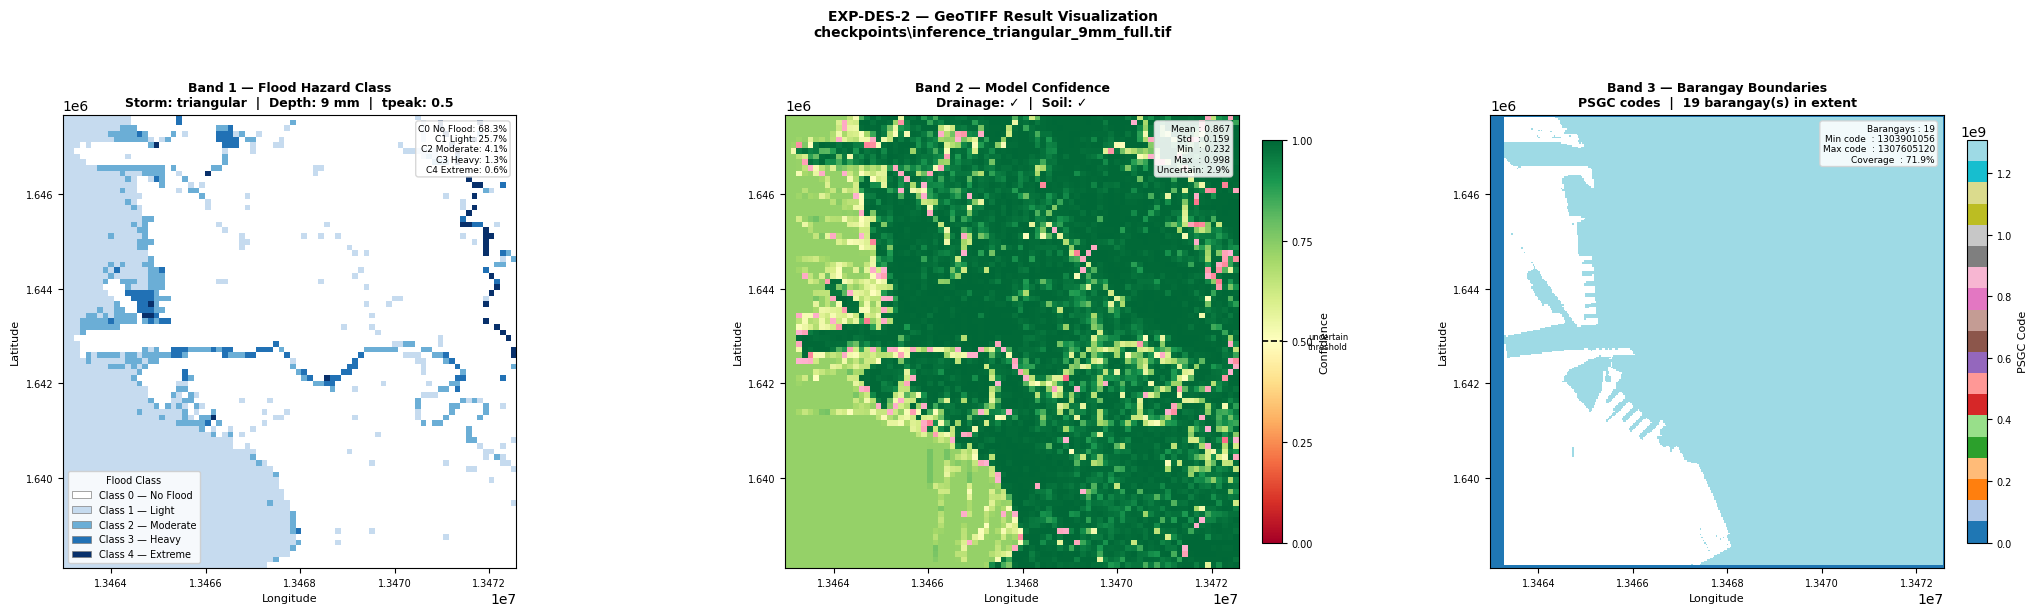


GeoTIFF: checkpoints\inference_triangular_9mm_drain_only.tif
  CRS       : EPSG:3857
  Extent    : [13462980.0, 13472580.0, 1638090.0, 1647690.0]
  Band 1    : Flood Hazard Class (0=None 1=Light 2=Moderate 3=Heavy 4=Extreme)
  Band 2    : Model Confidence (softmax max-probability per patch 0.0-1.0)
  Band 3    : Barangay PSGC Code (reprojected from manila_barangay.tif)
  Storm     : triangular  9mm  tpeak=0.5  Drainage=True  Soil=False
✓ Visualization saved → checkpoints\inference_triangular_9mm_drain_only_viz.png


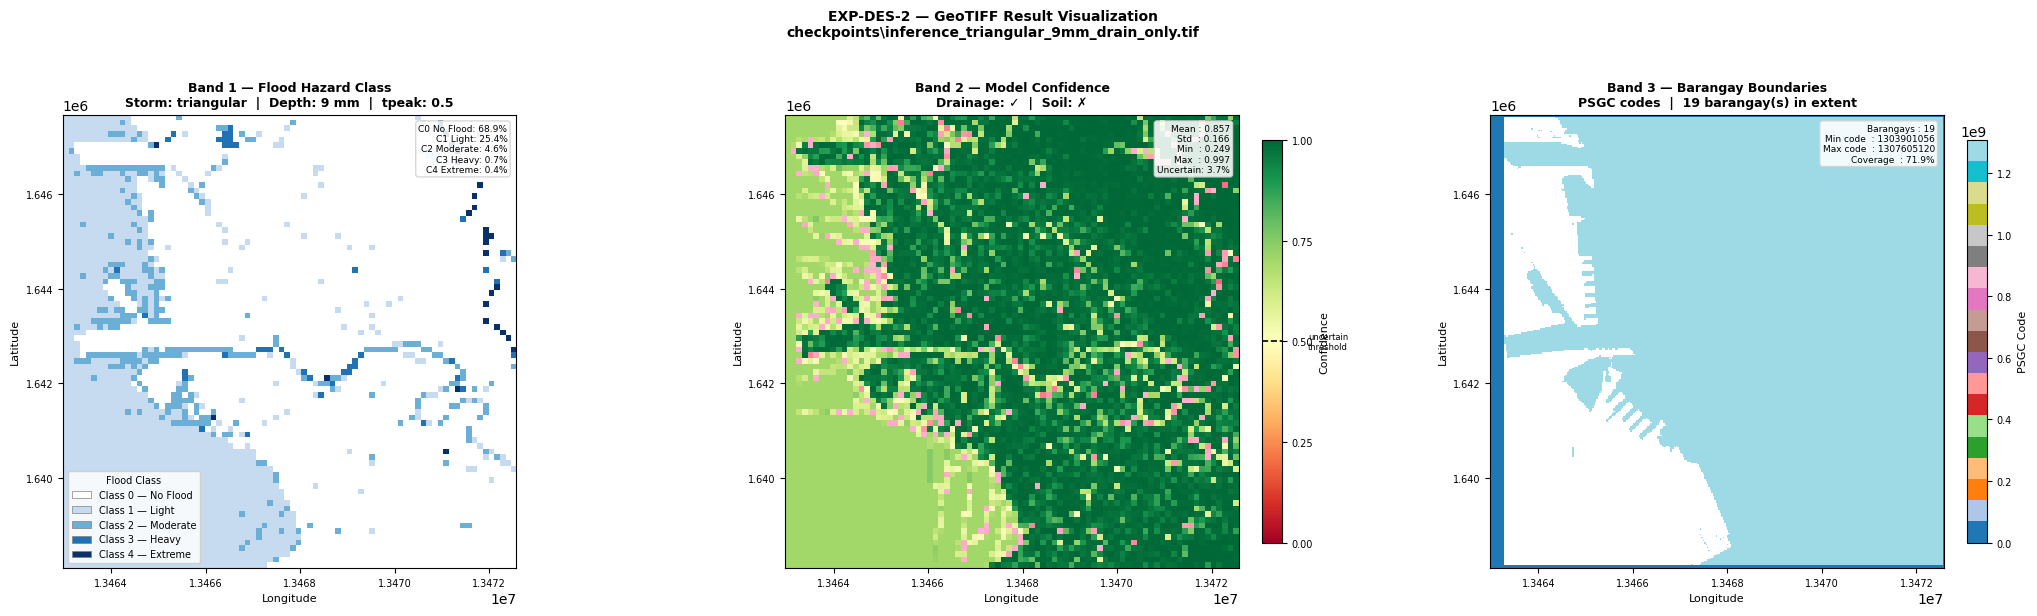


GeoTIFF: checkpoints\inference_triangular_9mm_soil_only.tif
  CRS       : EPSG:3857
  Extent    : [13462980.0, 13472580.0, 1638090.0, 1647690.0]
  Band 1    : Flood Hazard Class (0=None 1=Light 2=Moderate 3=Heavy 4=Extreme)
  Band 2    : Model Confidence (softmax max-probability per patch 0.0-1.0)
  Band 3    : Barangay PSGC Code (reprojected from manila_barangay.tif)
  Storm     : triangular  9mm  tpeak=0.5  Drainage=False  Soil=True
✓ Visualization saved → checkpoints\inference_triangular_9mm_soil_only_viz.png


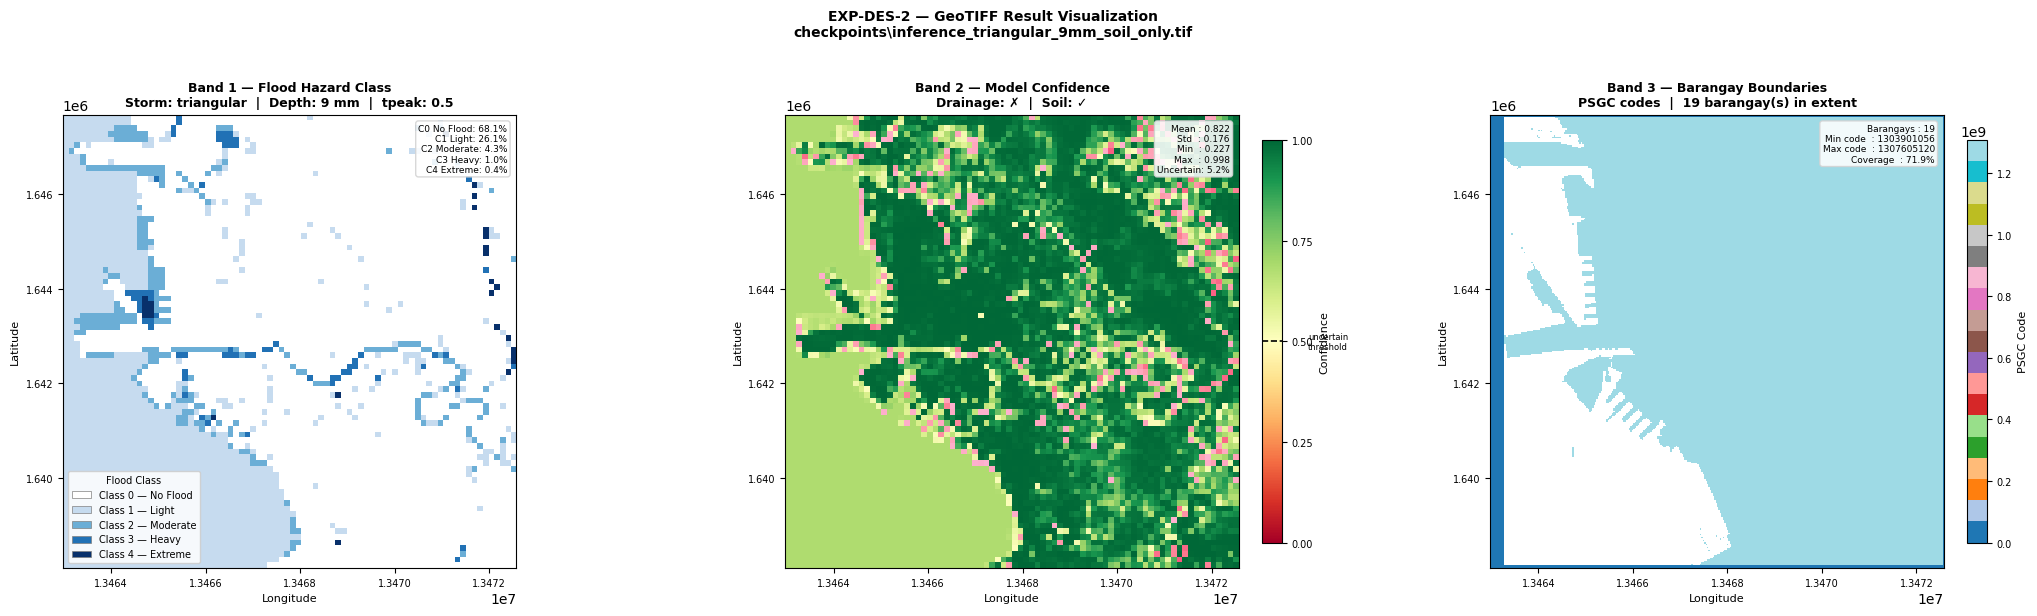


GeoTIFF: checkpoints\inference_triangular_9mm_minimal.tif
  CRS       : EPSG:3857
  Extent    : [13462980.0, 13472580.0, 1638090.0, 1647690.0]
  Band 1    : Flood Hazard Class (0=None 1=Light 2=Moderate 3=Heavy 4=Extreme)
  Band 2    : Model Confidence (softmax max-probability per patch 0.0-1.0)
  Band 3    : Barangay PSGC Code (reprojected from manila_barangay.tif)
  Storm     : triangular  9mm  tpeak=0.5  Drainage=False  Soil=False
✓ Visualization saved → checkpoints\inference_triangular_9mm_minimal_viz.png


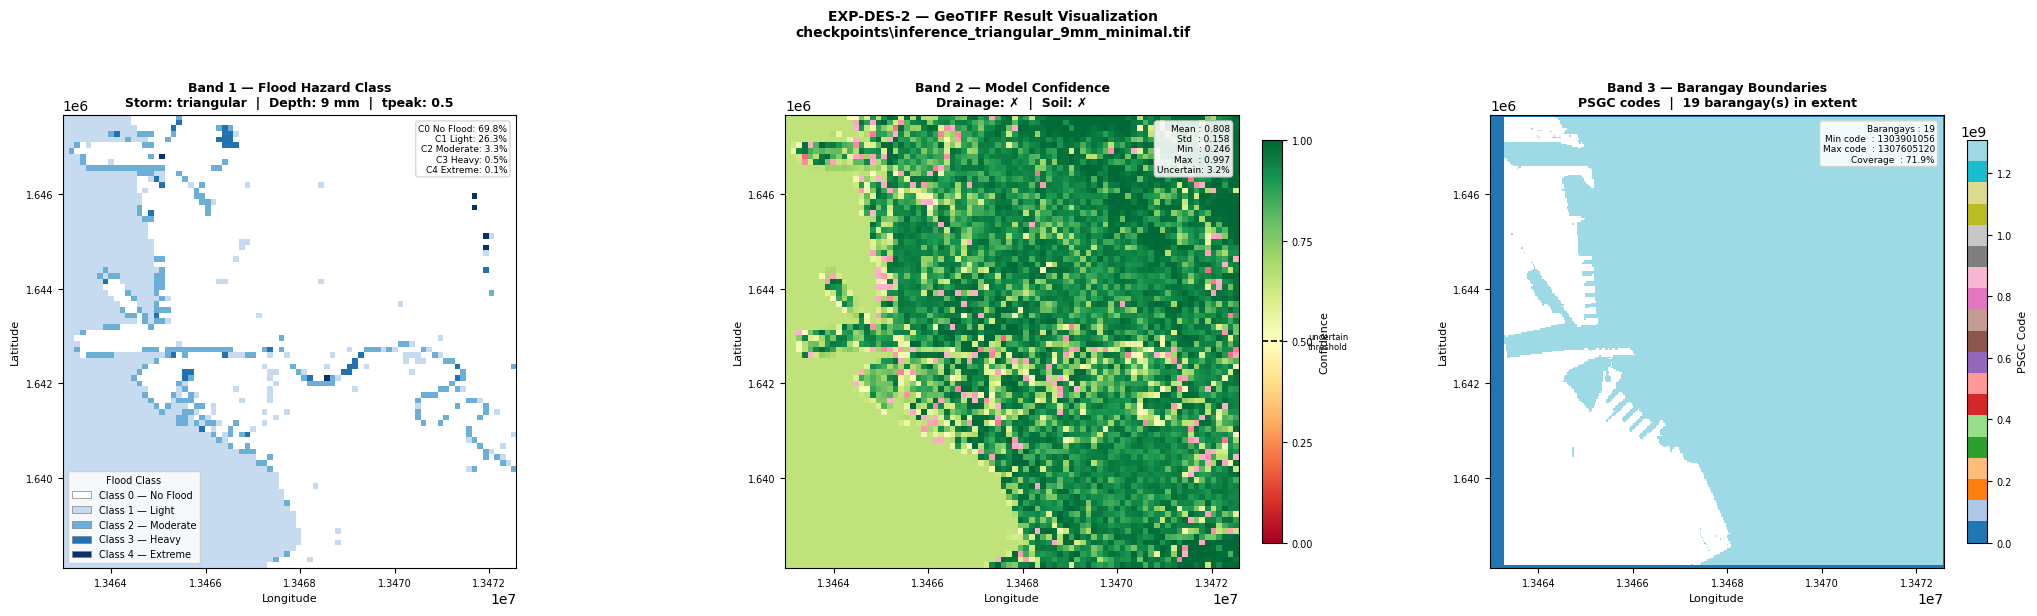


GeoTIFF: checkpoints\inference_front_loaded_34mm_full.tif
  CRS       : EPSG:3857
  Extent    : [13462980.0, 13472580.0, 1638090.0, 1647690.0]
  Band 1    : Flood Hazard Class (0=None 1=Light 2=Moderate 3=Heavy 4=Extreme)
  Band 2    : Model Confidence (softmax max-probability per patch 0.0-1.0)
  Band 3    : Barangay PSGC Code (reprojected from manila_barangay.tif)
  Storm     : front-loaded  34mm  tpeak=None  Drainage=True  Soil=True
✓ Visualization saved → checkpoints\inference_front_loaded_34mm_full_viz.png


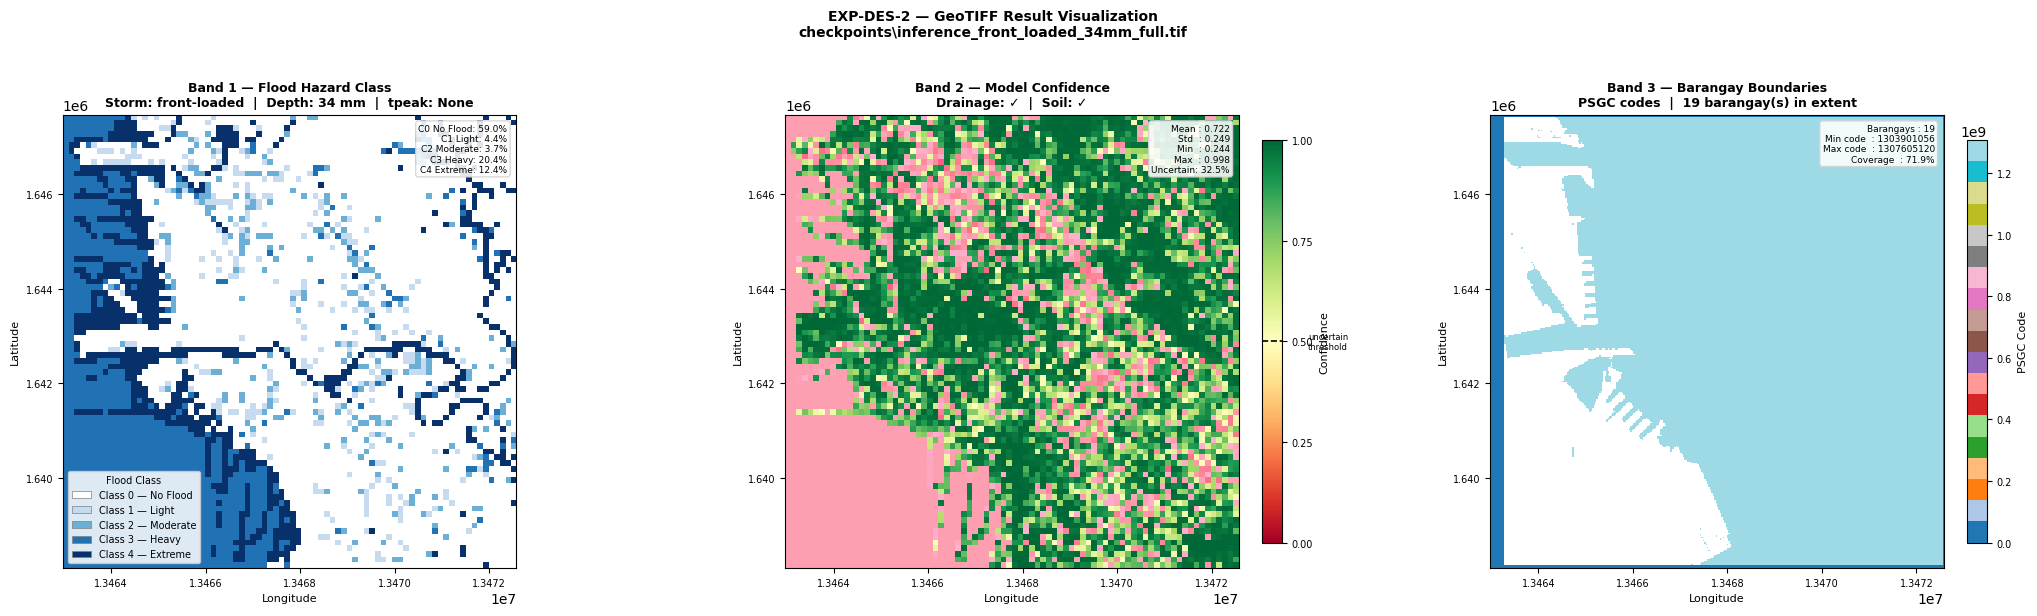


GeoTIFF: checkpoints\inference_front_loaded_34mm_drain_only.tif
  CRS       : EPSG:3857
  Extent    : [13462980.0, 13472580.0, 1638090.0, 1647690.0]
  Band 1    : Flood Hazard Class (0=None 1=Light 2=Moderate 3=Heavy 4=Extreme)
  Band 2    : Model Confidence (softmax max-probability per patch 0.0-1.0)
  Band 3    : Barangay PSGC Code (reprojected from manila_barangay.tif)
  Storm     : front-loaded  34mm  tpeak=None  Drainage=True  Soil=False
✓ Visualization saved → checkpoints\inference_front_loaded_34mm_drain_only_viz.png


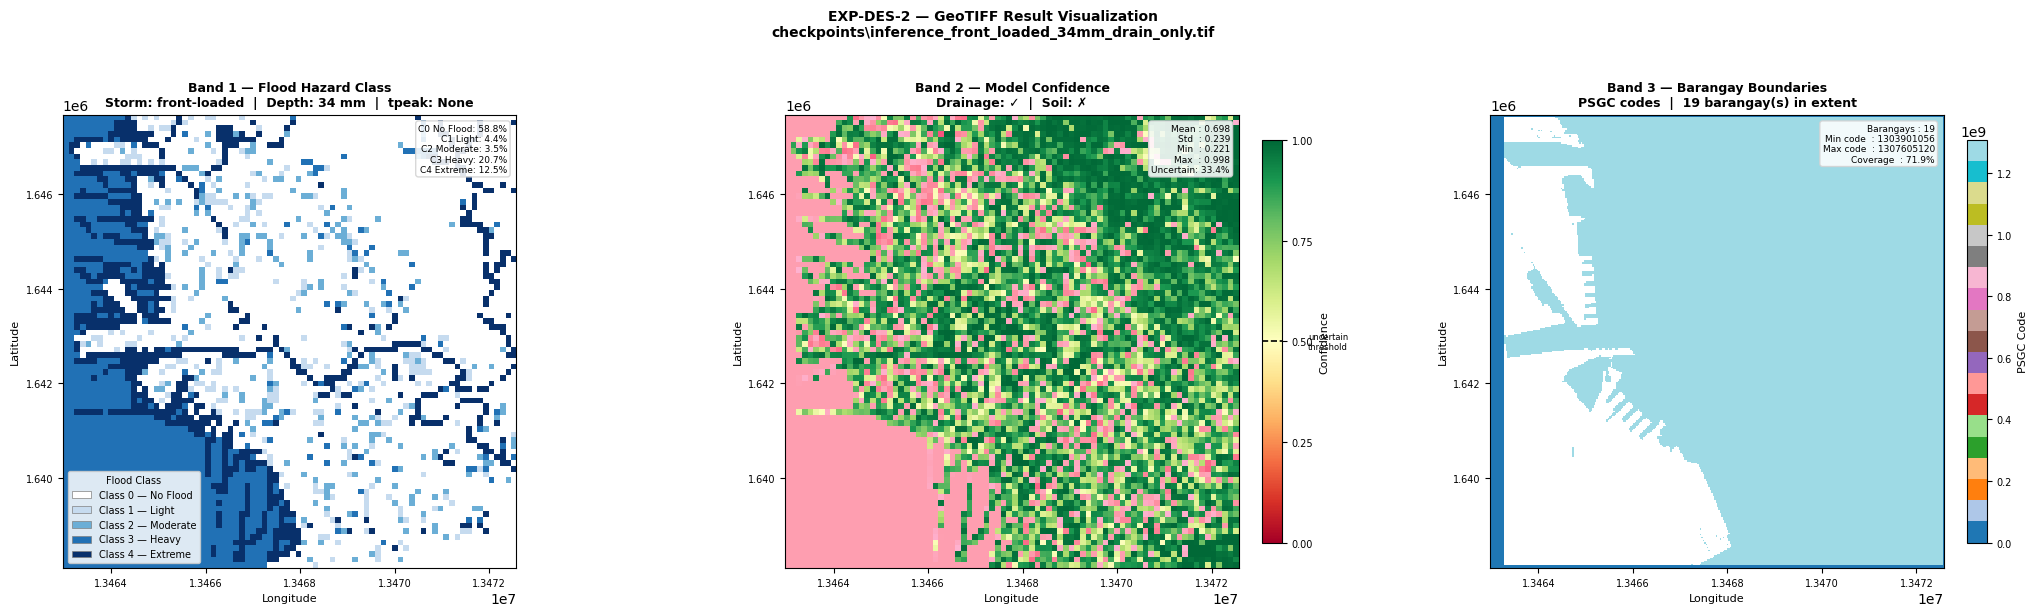


GeoTIFF: checkpoints\inference_front_loaded_34mm_soil_only.tif
  CRS       : EPSG:3857
  Extent    : [13462980.0, 13472580.0, 1638090.0, 1647690.0]
  Band 1    : Flood Hazard Class (0=None 1=Light 2=Moderate 3=Heavy 4=Extreme)
  Band 2    : Model Confidence (softmax max-probability per patch 0.0-1.0)
  Band 3    : Barangay PSGC Code (reprojected from manila_barangay.tif)
  Storm     : front-loaded  34mm  tpeak=None  Drainage=False  Soil=True
✓ Visualization saved → checkpoints\inference_front_loaded_34mm_soil_only_viz.png


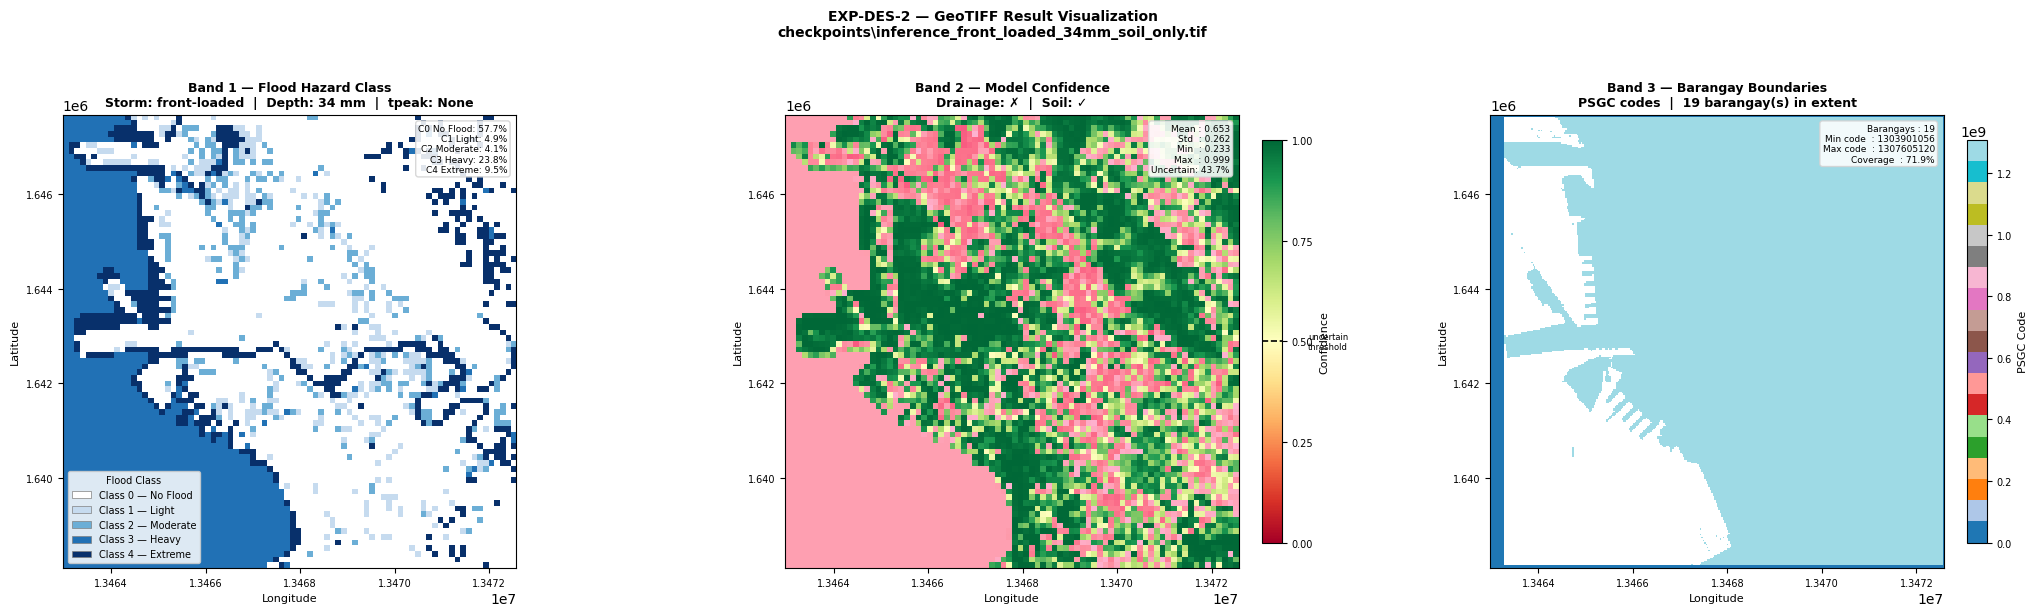


GeoTIFF: checkpoints\inference_front_loaded_34mm_minimal.tif
  CRS       : EPSG:3857
  Extent    : [13462980.0, 13472580.0, 1638090.0, 1647690.0]
  Band 1    : Flood Hazard Class (0=None 1=Light 2=Moderate 3=Heavy 4=Extreme)
  Band 2    : Model Confidence (softmax max-probability per patch 0.0-1.0)
  Band 3    : Barangay PSGC Code (reprojected from manila_barangay.tif)
  Storm     : front-loaded  34mm  tpeak=None  Drainage=False  Soil=False
✓ Visualization saved → checkpoints\inference_front_loaded_34mm_minimal_viz.png


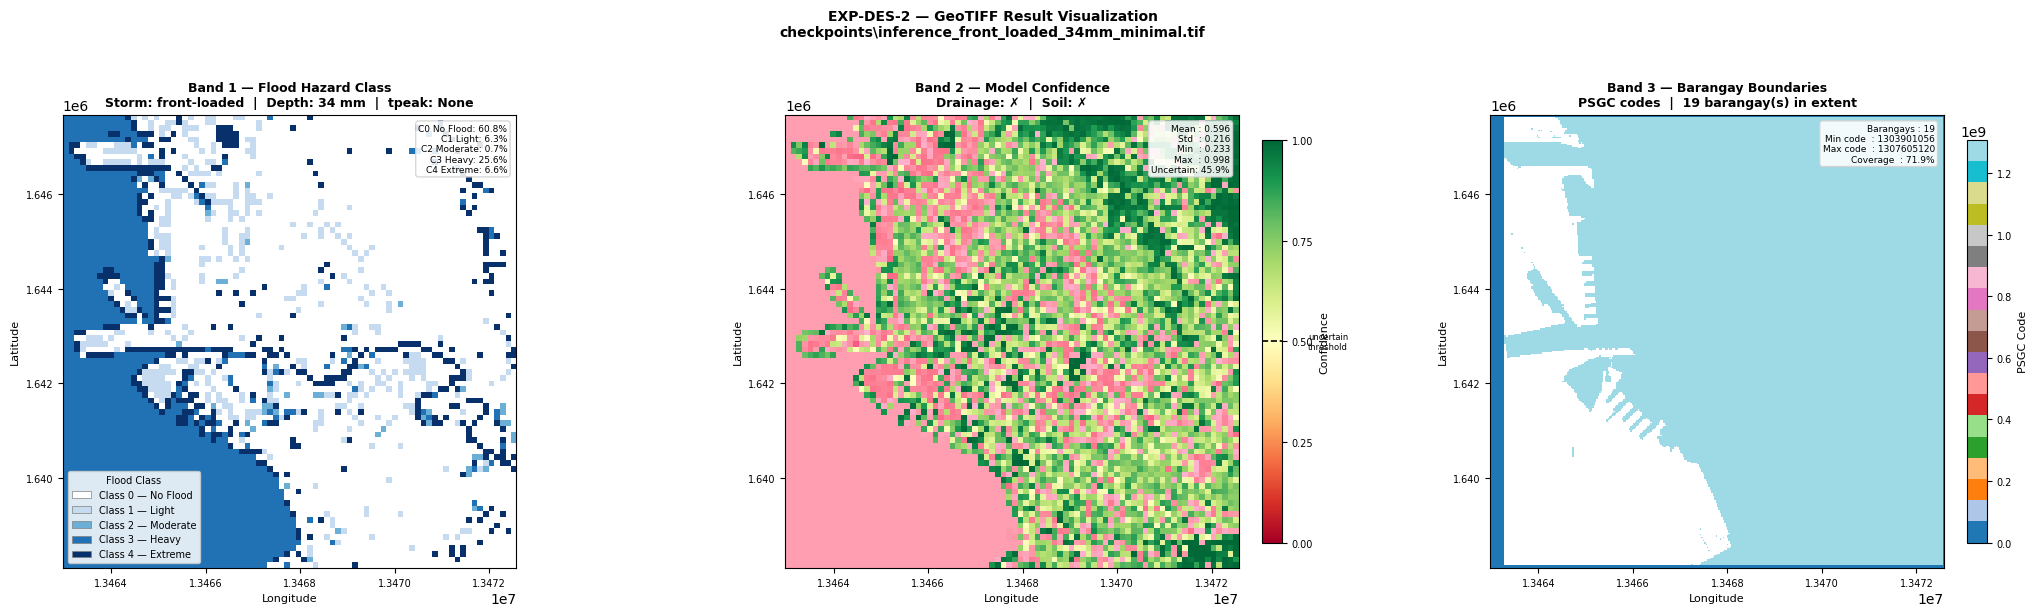


GeoTIFF: checkpoints\inference_balanced_31mm_full.tif
  CRS       : EPSG:3857
  Extent    : [13462980.0, 13472580.0, 1638090.0, 1647690.0]
  Band 1    : Flood Hazard Class (0=None 1=Light 2=Moderate 3=Heavy 4=Extreme)
  Band 2    : Model Confidence (softmax max-probability per patch 0.0-1.0)
  Band 3    : Barangay PSGC Code (reprojected from manila_barangay.tif)
  Storm     : balanced  31mm  tpeak=None  Drainage=True  Soil=True
✓ Visualization saved → checkpoints\inference_balanced_31mm_full_viz.png


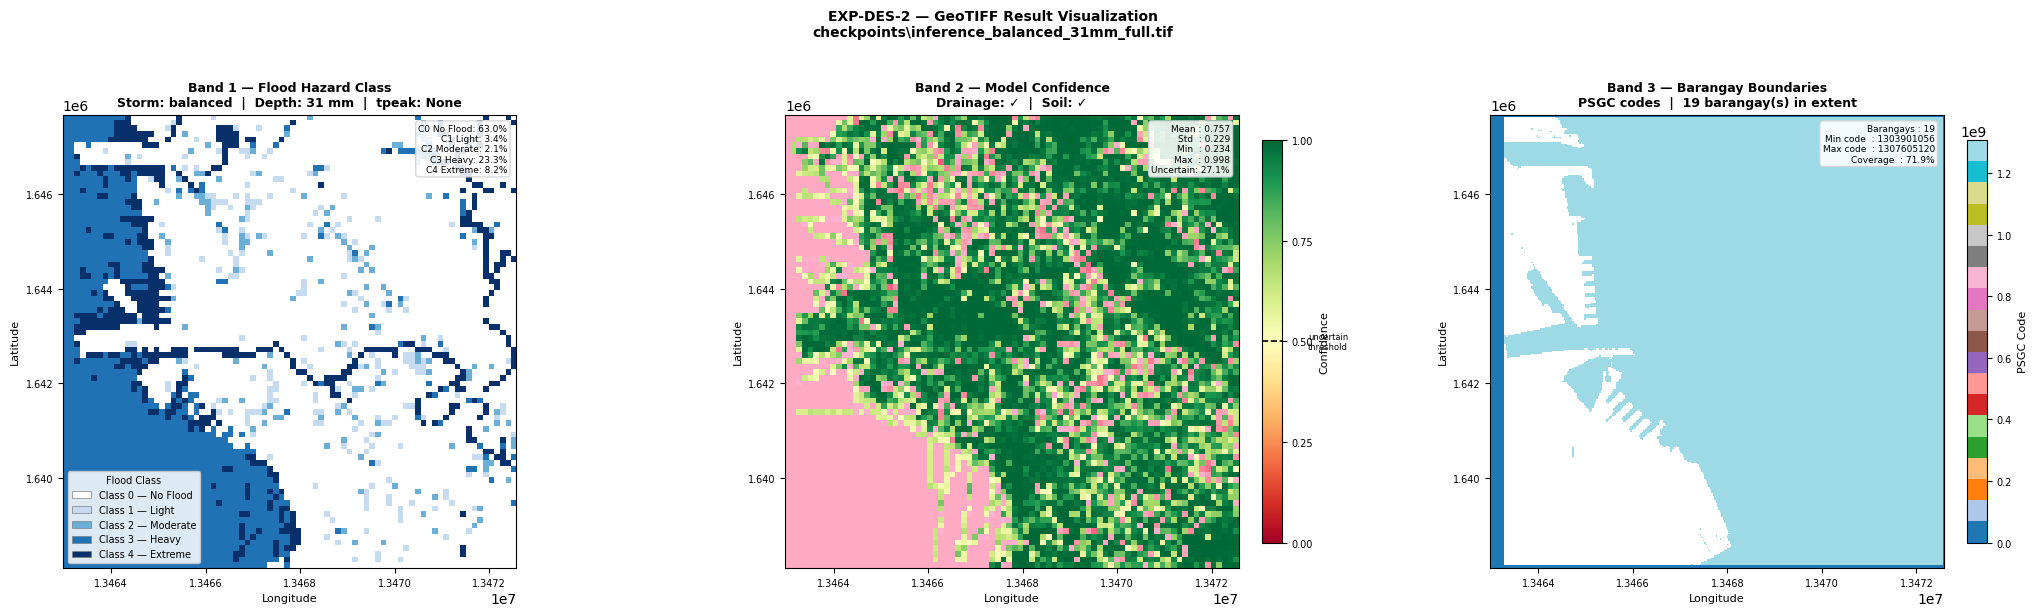


GeoTIFF: checkpoints\inference_balanced_31mm_drain_only.tif
  CRS       : EPSG:3857
  Extent    : [13462980.0, 13472580.0, 1638090.0, 1647690.0]
  Band 1    : Flood Hazard Class (0=None 1=Light 2=Moderate 3=Heavy 4=Extreme)
  Band 2    : Model Confidence (softmax max-probability per patch 0.0-1.0)
  Band 3    : Barangay PSGC Code (reprojected from manila_barangay.tif)
  Storm     : balanced  31mm  tpeak=None  Drainage=True  Soil=False
✓ Visualization saved → checkpoints\inference_balanced_31mm_drain_only_viz.png


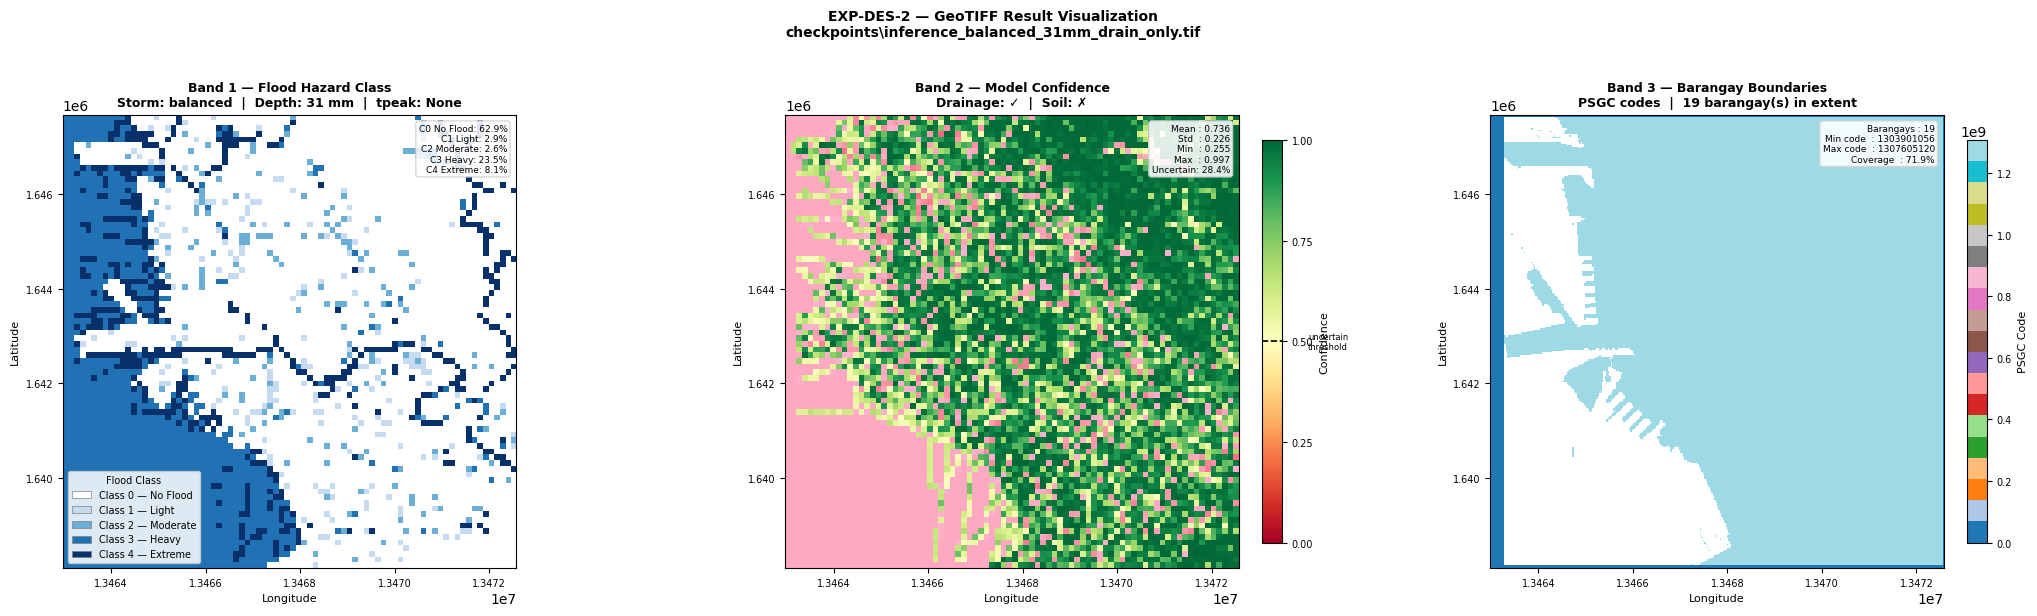


GeoTIFF: checkpoints\inference_balanced_31mm_soil_only.tif
  CRS       : EPSG:3857
  Extent    : [13462980.0, 13472580.0, 1638090.0, 1647690.0]
  Band 1    : Flood Hazard Class (0=None 1=Light 2=Moderate 3=Heavy 4=Extreme)
  Band 2    : Model Confidence (softmax max-probability per patch 0.0-1.0)
  Band 3    : Barangay PSGC Code (reprojected from manila_barangay.tif)
  Storm     : balanced  31mm  tpeak=None  Drainage=False  Soil=True
✓ Visualization saved → checkpoints\inference_balanced_31mm_soil_only_viz.png


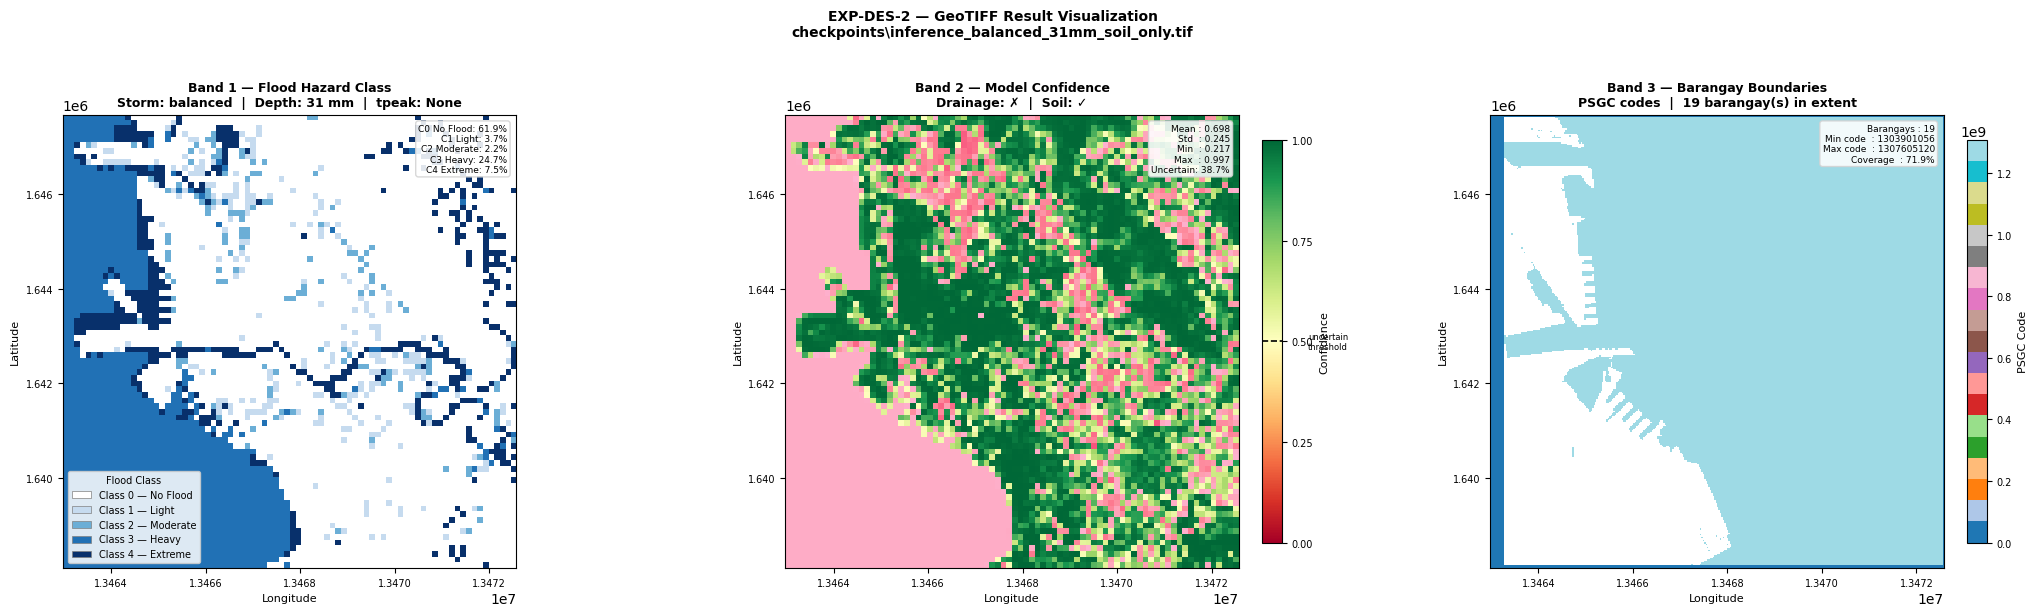


GeoTIFF: checkpoints\inference_balanced_31mm_minimal.tif
  CRS       : EPSG:3857
  Extent    : [13462980.0, 13472580.0, 1638090.0, 1647690.0]
  Band 1    : Flood Hazard Class (0=None 1=Light 2=Moderate 3=Heavy 4=Extreme)
  Band 2    : Model Confidence (softmax max-probability per patch 0.0-1.0)
  Band 3    : Barangay PSGC Code (reprojected from manila_barangay.tif)
  Storm     : balanced  31mm  tpeak=None  Drainage=False  Soil=False
✓ Visualization saved → checkpoints\inference_balanced_31mm_minimal_viz.png


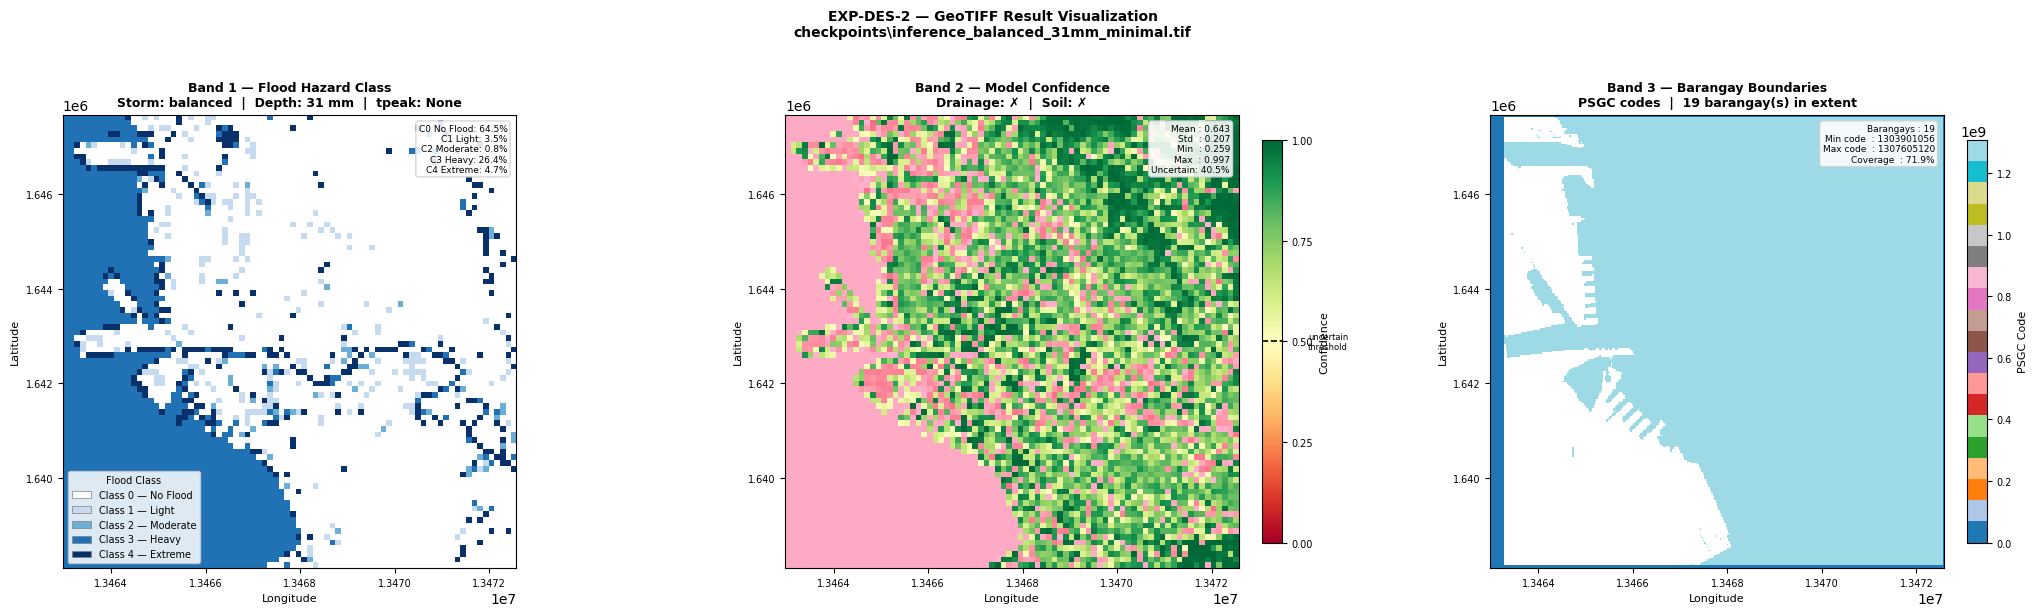


GeoTIFF: checkpoints\inference_back_loaded_35mm_full.tif
  CRS       : EPSG:3857
  Extent    : [13462980.0, 13472580.0, 1638090.0, 1647690.0]
  Band 1    : Flood Hazard Class (0=None 1=Light 2=Moderate 3=Heavy 4=Extreme)
  Band 2    : Model Confidence (softmax max-probability per patch 0.0-1.0)
  Band 3    : Barangay PSGC Code (reprojected from manila_barangay.tif)
  Storm     : back-loaded  35mm  tpeak=None  Drainage=True  Soil=True
✓ Visualization saved → checkpoints\inference_back_loaded_35mm_full_viz.png


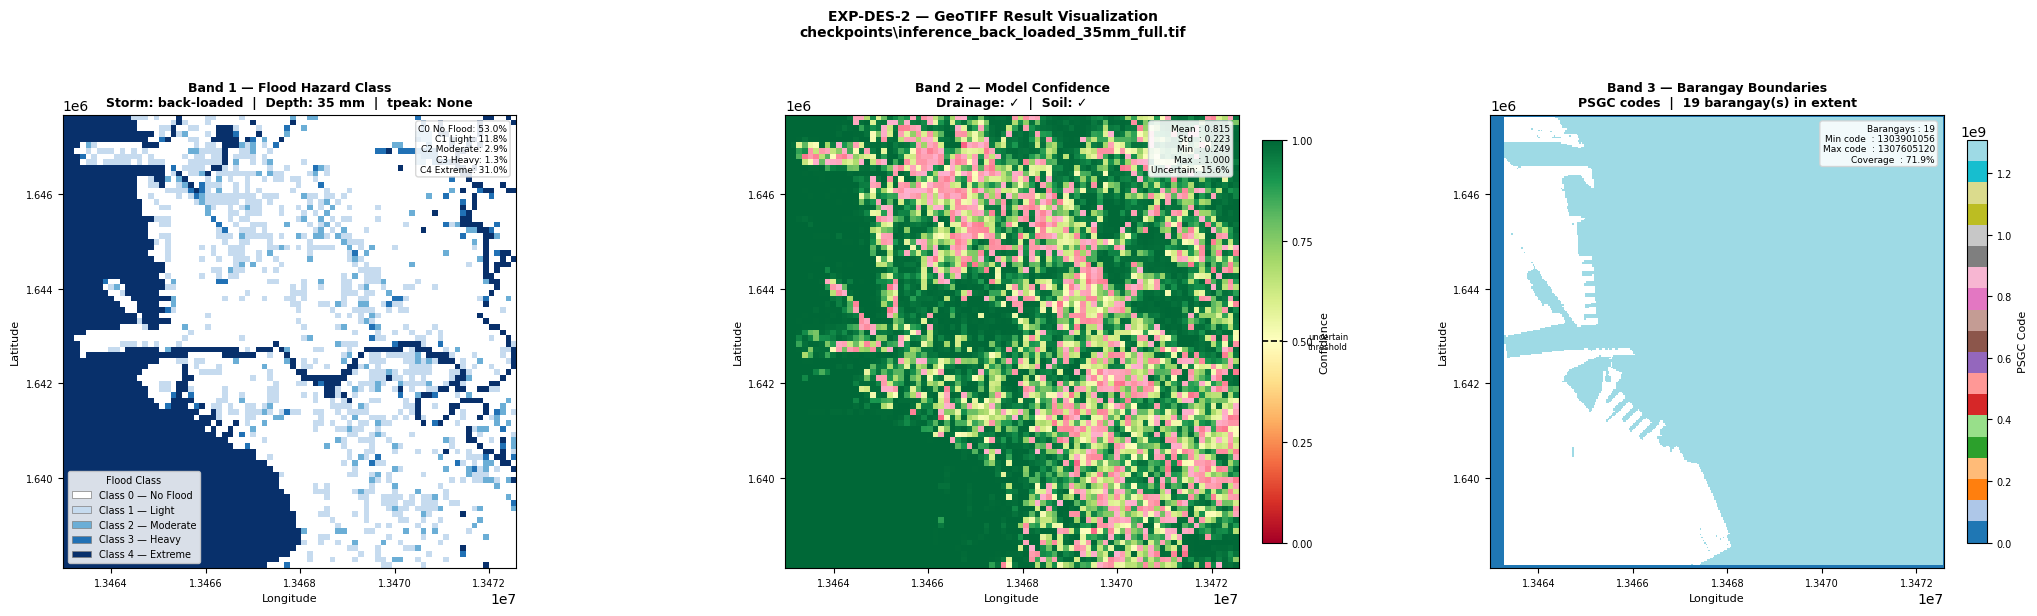


GeoTIFF: checkpoints\inference_back_loaded_35mm_drain_only.tif
  CRS       : EPSG:3857
  Extent    : [13462980.0, 13472580.0, 1638090.0, 1647690.0]
  Band 1    : Flood Hazard Class (0=None 1=Light 2=Moderate 3=Heavy 4=Extreme)
  Band 2    : Model Confidence (softmax max-probability per patch 0.0-1.0)
  Band 3    : Barangay PSGC Code (reprojected from manila_barangay.tif)
  Storm     : back-loaded  35mm  tpeak=None  Drainage=True  Soil=False
✓ Visualization saved → checkpoints\inference_back_loaded_35mm_drain_only_viz.png


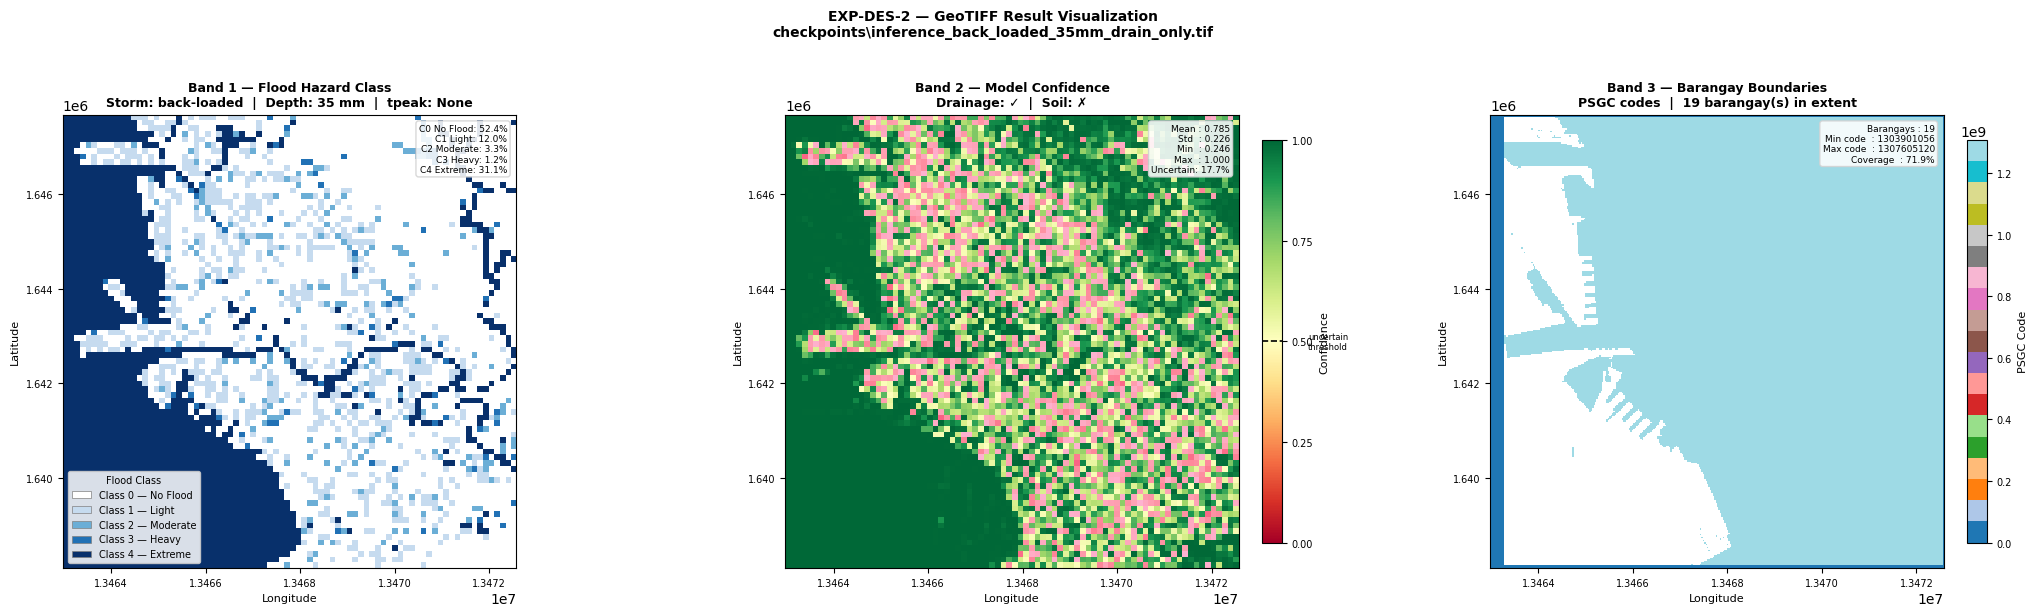


GeoTIFF: checkpoints\inference_back_loaded_35mm_soil_only.tif
  CRS       : EPSG:3857
  Extent    : [13462980.0, 13472580.0, 1638090.0, 1647690.0]
  Band 1    : Flood Hazard Class (0=None 1=Light 2=Moderate 3=Heavy 4=Extreme)
  Band 2    : Model Confidence (softmax max-probability per patch 0.0-1.0)
  Band 3    : Barangay PSGC Code (reprojected from manila_barangay.tif)
  Storm     : back-loaded  35mm  tpeak=None  Drainage=False  Soil=True
✓ Visualization saved → checkpoints\inference_back_loaded_35mm_soil_only_viz.png


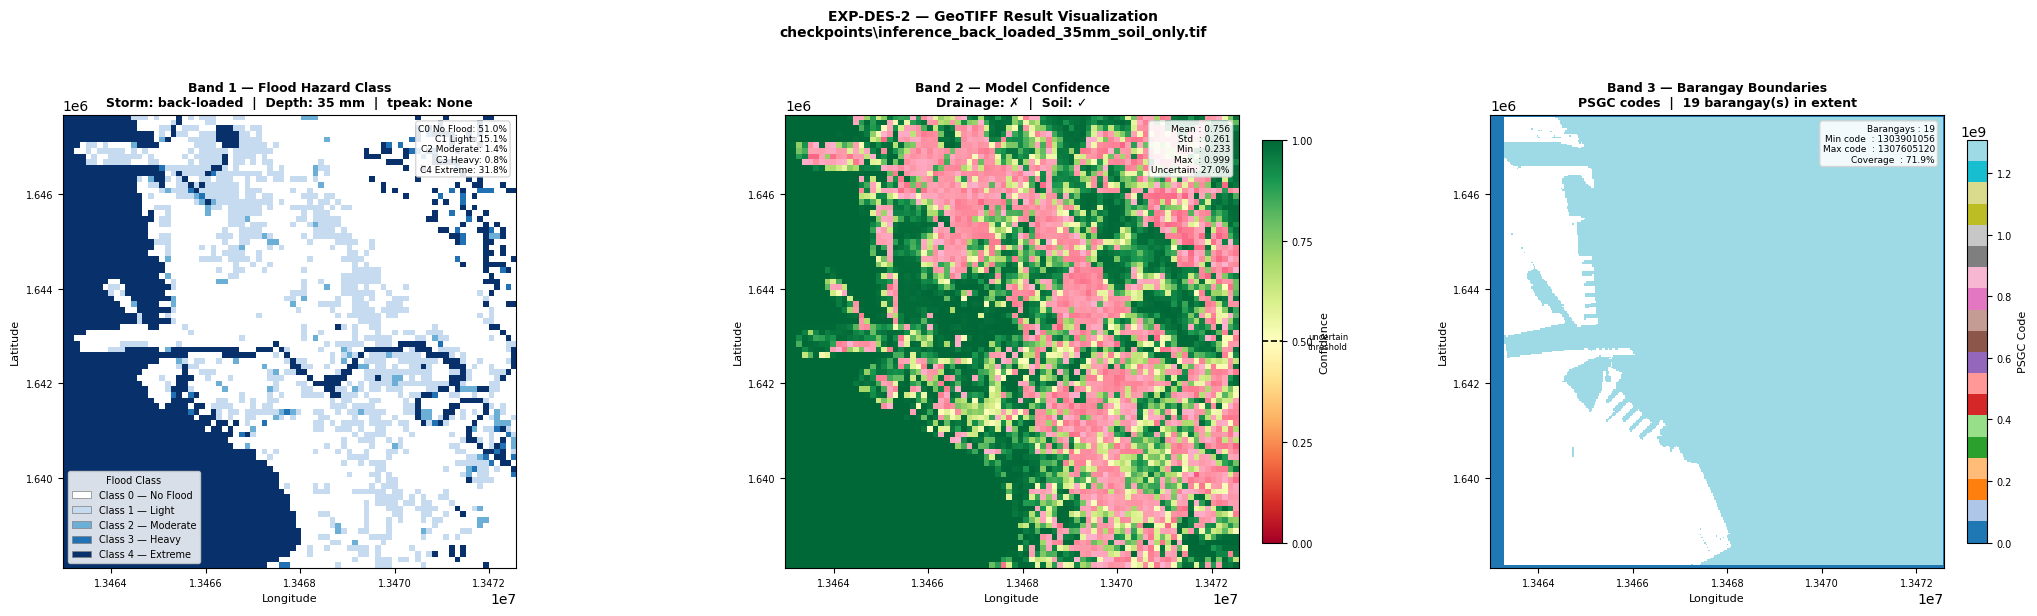


GeoTIFF: checkpoints\inference_back_loaded_35mm_minimal.tif
  CRS       : EPSG:3857
  Extent    : [13462980.0, 13472580.0, 1638090.0, 1647690.0]
  Band 1    : Flood Hazard Class (0=None 1=Light 2=Moderate 3=Heavy 4=Extreme)
  Band 2    : Model Confidence (softmax max-probability per patch 0.0-1.0)
  Band 3    : Barangay PSGC Code (reprojected from manila_barangay.tif)
  Storm     : back-loaded  35mm  tpeak=None  Drainage=False  Soil=False
✓ Visualization saved → checkpoints\inference_back_loaded_35mm_minimal_viz.png


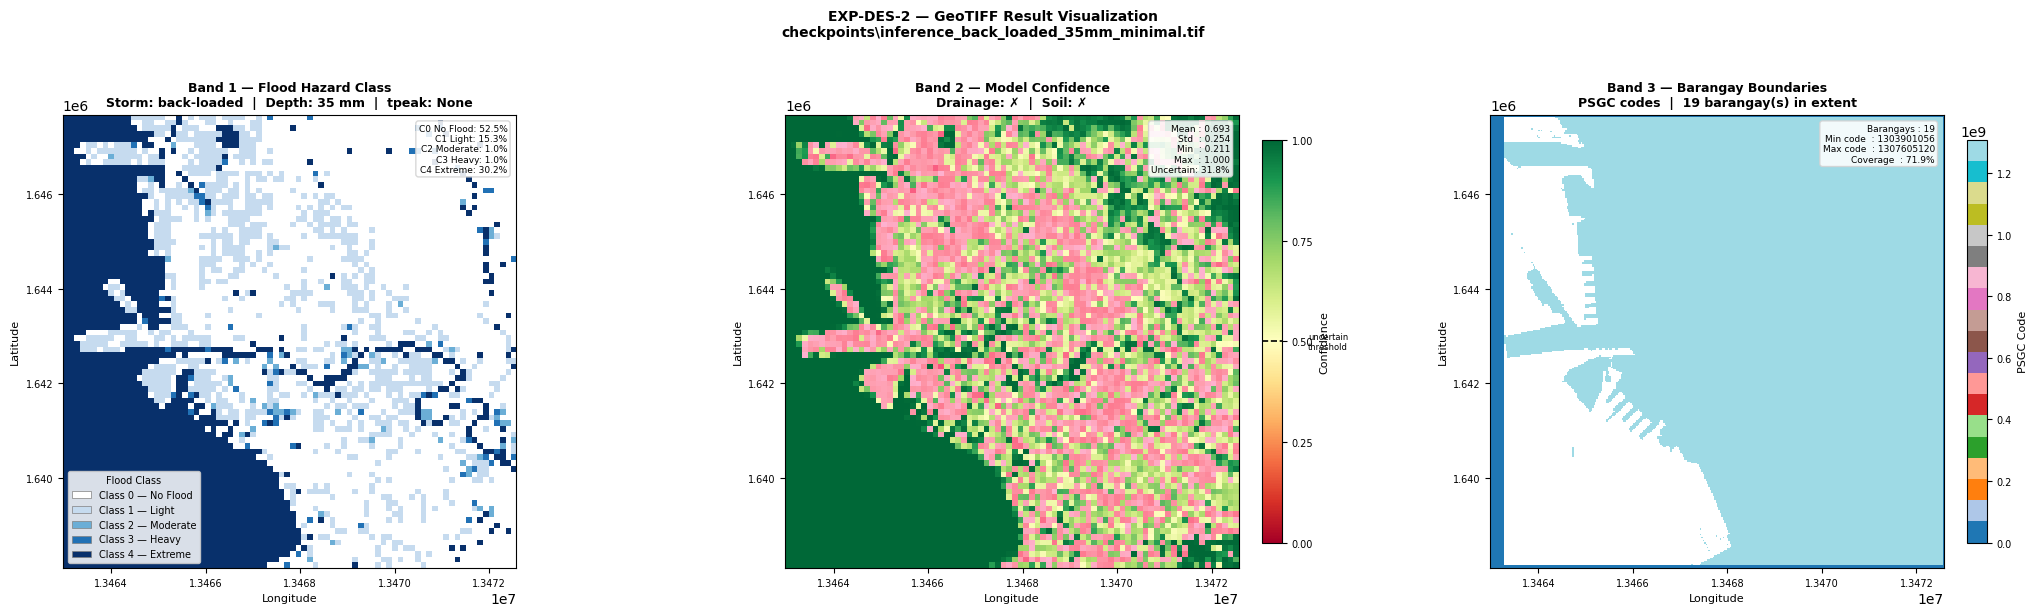

In [4]:
# ── Visualize all 16 saved TIFFs ─────────────────────────────────────────────
for sc in STORM_CONFIGS:
    slug = save_slugs[sc['storm_label']]
    for ab in ABLATION_CONFIGS:
        ab_slug  = ablation_slugs[ab['label']]
        tif_name = f'inference_{slug}_{ab_slug}.tif'
        viz_name = f'inference_{slug}_{ab_slug}_viz.png'

        visualize_result_tif(
            tif_path  = str(cfg.train.output_dir / tif_name),
            save_path = str(cfg.train.output_dir / viz_name),
        )